# 2021–2024 통합 모델 비교

4,068명 전원·5-fold. 공통 틀 실험과 모델별 학습법을 살린 비교를 구분한다. 저장된 집계를 다시 표시하며 학습 재실행은 하지 않는다.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
DATA=json.loads('{"common_control_all_years": {"plan": {"purpose": "Use all four years in pooled training/evaluation, with leakage-safe out-of-fold predictions", "years": [2021, 2022, 2023, 2024], "cohort": "Same strict4068, no change to clinical target/exclusions", "outer": "Five StratifiedGroupKFold folds, stratification year x any-abnormality, PSU groups year:psu, shuffle seed20260923", "inner": "Within each outer development set, ten grouped folds; first for validation, second for calibration, remaining eight for fit. All four years in each role.", "selection": "Two settings per family, validation clean/masked macroAP mean, no outer-test selection. One fixed training seed42 per fit; fivefold variation is not three-seed stability.", "preprocessing": "Fit only inner fit participants, then reuse for validation/calibration/test. Same19 inputs and derived basis for all families.", "augmentation": "Every family receives identical clean + one missing20 view of inner fit rows; weights duplicated symmetrically. No synthetic participants.", "masking": "Do not mask age/sex; tie waist and WHtR masking. Three fixed masks for validation and outer-test; one for calibration.", "neural": "Frozen LR residual adapters from v8; group_hurdle control. Common NLL/4+.2 marginal BCE,120max epochs,patience25,lr .001/.0003,wd .001. Includes epoch0.", "baselines": "LR_basis,RF,HGB settings unchanged from v8", "calibration": "Single temperature on inner calibration joint NLL, equal clean/masked weighting; no final refit on calibration rows", "primary": "Pooled OOF four-label weighted macroAP, clean and missing20 separately, Brier and AUC secondary", "uncertainty": "200 full-frame year/stratum PSU resamples of fixed OOF predictions. Shared people/masks paired. Does not include training/selection uncertainty.", "interpretation": "Pooled cross-year validation, not forecasting a new survey year. Earlier data-informed architecture choices make this exploratory, not fresh external validation.", "classification": "No threshold tuning; optional F1/Hamming use .5 only. Selection uses threshold-free AP.", "status": "No service model replacement; preserve v7/v8 temporal experiments"}, "years": {"2021": 1039, "2022": 1013, "2023": 1010, "2024": 1006}, "cohort_flow": {"2021": {"all": 7090, "age_19_39": 1414, "known_diagnosis_status": 1321, "no_prior_diagnosis": 1269, "no_medication": 1269, "not_recorded_pregnant": 1258, "fasting": 1061, "complete_target": 1039, "valid_survey_design": 1039}, "2022": {"all": 6265, "age_19_39": 1284, "known_diagnosis_status": 1284, "no_prior_diagnosis": 1229, "no_medication": 1229, "not_recorded_pregnant": 1212, "fasting": 1035, "complete_target": 1013, "valid_survey_design": 1013}, "2023": {"all": 6929, "age_19_39": 1290, "known_diagnosis_status": 1290, "no_prior_diagnosis": 1237, "no_medication": 1237, "not_recorded_pregnant": 1220, "fasting": 1027, "complete_target": 1010, "valid_survey_design": 1010}, "2024": {"all": 6997, "age_19_39": 1353, "known_diagnosis_status": 1353, "no_prior_diagnosis": 1280, "no_medication": 1280, "not_recorded_pregnant": 1267, "fasting": 1011, "complete_target": 1006, "valid_survey_design": 1006}}, "fold_audit": [{"fold": 1, "roles": {"fit": {"n": 2664, "years": {"2021": 682, "2022": 753, "2023": 586, "2024": 643}, "psus": 452}, "validation": {"n": 295, "years": {"2021": 105, "2022": 46, "2023": 66, "2024": 78}, "psus": 54}, "calibration": {"n": 273, "years": {"2021": 45, "2022": 45, "2023": 94, "2024": 89}, "psus": 53}, "test": {"n": 836, "years": {"2021": 207, "2022": 169, "2023": 264, "2024": 196}, "psus": 140}}}, {"fold": 2, "roles": {"fit": {"n": 2607, "years": {"2021": 642, "2022": 612, "2023": 699, "2024": 654}, "psus": 447}, "validation": {"n": 294, "years": {"2021": 96, "2022": 82, "2023": 54, "2024": 62}, "psus": 56}, "calibration": {"n": 380, "years": {"2021": 86, "2022": 87, "2023": 99, "2024": 108}, "psus": 55}, "test": {"n": 787, "years": {"2021": 215, "2022": 232, "2023": 158, "2024": 182}, "psus": 141}}}, {"fold": 3, "roles": {"fit": {"n": 2634, "years": {"2021": 690, "2022": 663, "2023": 698, "2024": 583}, "psus": 450}, "validation": {"n": 305, "years": {"2021": 92, "2022": 57, "2023": 62, "2024": 94}, "psus": 56}, "calibration": {"n": 263, "years": {"2021": 56, "2022": 66, "2023": 62, "2024": 79}, "psus": 54}, "test": {"n": 866, "years": {"2021": 201, "2022": 227, "2023": 188, "2024": 250}, "psus": 139}}}, {"fold": 4, "roles": {"fit": {"n": 2590, "years": {"2021": 673, "2022": 640, "2023": 656, "2024": 621}, "psus": 447}, "validation": {"n": 330, "years": {"2021": 83, "2022": 93, "2023": 63, "2024": 91}, "psus": 56}, "calibration": {"n": 344, "years": {"2021": 74, "2022": 99, "2023": 97, "2024": 74}, "psus": 57}, "test": {"n": 804, "years": {"2021": 209, "2022": 181, "2023": 194, "2024": 220}, "psus": 139}}}, {"fold": 5, "roles": {"fit": {"n": 2570, "years": {"2021": 578, "2022": 662, "2023": 637, "2024": 693}, "psus": 448}, "validation": {"n": 371, "years": {"2021": 135, "2022": 79, "2023": 98, "2024": 59}, "psus": 56}, "calibration": {"n": 352, "years": {"2021": 119, "2022": 68, "2023": 69, "2024": 96}, "psus": 55}, "test": {"n": 775, "years": {"2021": 207, "2022": 204, "2023": 206, "2024": 158}, "psus": 140}}}], "models": {"LR_basis": {"clean": {"macro_ap": 0.36633880326375057, "macro_auc": 0.7788253612334929, "macro_brier": 0.10607896934823241, "micro_ap": 0.38293847668417846, "macro_f1": 0.2099139227333139, "hamming_loss": 0.1433068531451303, "subset_accuracy": 0.6057935534778442, "joint_argmax_accuracy": 0.6057935534778442, "joint_nll": 1.3852240957005626, "any_auc": 0.7883881809349838, "count_mae": 0.5487513458278909, "per_label": {"0": {"ap": 0.3716142643413113, "auc": 0.8011232082097627, "brier": 0.09573725113673794}, "1": {"ap": 0.2679829714836707, "auc": 0.7590585738985682, "brier": 0.08295018095396238}, "2": {"ap": 0.4406949097058467, "auc": 0.7959511746658867, "brier": 0.1259762535800354}, "3": {"ap": 0.3850630675241734, "auc": 0.7591684881597538, "brier": 0.11965219172219392}}}, "missing20": {"macro_ap": 0.3441044824610109, "macro_auc": 0.7592773277496457, "macro_brier": 0.10845793576288809, "micro_ap": 0.36017127356304535, "macro_f1": 0.1576204448588724, "hamming_loss": 0.14307827275668353, "subset_accuracy": 0.6129345309259765, "joint_argmax_accuracy": 0.6129345309259765, "joint_nll": 1.4216273001505435, "any_auc": 0.7658406270664333, "count_mae": 0.5807967378284902}, "per_year": {"2021": {"n": 1039, "clean_macro_ap": 0.40451802904393397, "missing_macro_ap": 0.3817033154669473}, "2022": {"n": 1013, "clean_macro_ap": 0.3489217898097925, "missing_macro_ap": 0.33123632200650055}, "2023": {"n": 1010, "clean_macro_ap": 0.34781885796611395, "missing_macro_ap": 0.31925979052883946}, "2024": {"n": 1006, "clean_macro_ap": 0.39863061981427167, "missing_macro_ap": 0.37450054867858124}}}, "RandomForest": {"clean": {"macro_ap": 0.35120749213213726, "macro_auc": 0.7731425995172555, "macro_brier": 0.10678721293418042, "micro_ap": 0.37281787145282536, "macro_f1": 0.16587274101556598, "hamming_loss": 0.1426727176100894, "subset_accuracy": 0.6100574450425118, "joint_argmax_accuracy": 0.6100574450425118, "joint_nll": 1.3972600696652262, "any_auc": 0.7874511463630688, "count_mae": 0.5500970347095774, "per_label": {"0": {"ap": 0.3522816342045047, "auc": 0.7897636893245135, "brier": 0.09722403884695072}, "1": {"ap": 0.24865463580689295, "auc": 0.7600456784217495, "brier": 0.08354948961614561}, "2": {"ap": 0.44537070867118467, "auc": 0.7946627381373232, "brier": 0.12513977111639474}, "3": {"ap": 0.3585229898459667, "auc": 0.748098292185436, "brier": 0.12123555215723059}}}, "missing20": {"macro_ap": 0.3378666671576272, "macro_auc": 0.7598897656887544, "macro_brier": 0.10845534356419202, "micro_ap": 0.35769273611073654, "macro_f1": 0.12630932498434017, "hamming_loss": 0.14394160188419192, "subset_accuracy": 0.6121271721450514, "joint_argmax_accuracy": 0.6121271721450514, "joint_nll": 1.4234582330258538, "any_auc": 0.7697637188503954, "count_mae": 0.5726199989406306}, "per_year": {"2021": {"n": 1039, "clean_macro_ap": 0.3746098656510422, "missing_macro_ap": 0.3594340709262058}, "2022": {"n": 1013, "clean_macro_ap": 0.3363326884520369, "missing_macro_ap": 0.32448301726765455}, "2023": {"n": 1010, "clean_macro_ap": 0.3463618291219345, "missing_macro_ap": 0.32958218899124897}, "2024": {"n": 1006, "clean_macro_ap": 0.38539902991653563, "missing_macro_ap": 0.3725833598374259}}}, "HistGradientBoosting": {"clean": {"macro_ap": 0.34769130360199096, "macro_auc": 0.7725183850640256, "macro_brier": 0.10731130682929993, "micro_ap": 0.36618554041024354, "macro_f1": 0.17635684779864286, "hamming_loss": 0.14594679881594558, "subset_accuracy": 0.6088386920630933, "joint_argmax_accuracy": 0.6088386920630933, "joint_nll": 1.399916910094206, "any_auc": 0.787780671245483, "count_mae": 0.5520445917660735, "per_label": {"0": {"ap": 0.3351533879966945, "auc": 0.7896108377539737, "brier": 0.09821632880704453}, "1": {"ap": 0.254141525335173, "auc": 0.7560179834017176, "brier": 0.08379767506744455}, "2": {"ap": 0.437914922595613, "auc": 0.7956473158185013, "brier": 0.1258829066361707}, "3": {"ap": 0.3635553784804835, "auc": 0.74879740328191, "brier": 0.12134831680653997}}}, "missing20": {"macro_ap": 0.3375744104839236, "macro_auc": 0.7595120489602966, "macro_brier": 0.10868577303469362, "micro_ap": 0.35485300295308936, "macro_f1": 0.1423460268385496, "hamming_loss": 0.14521342457031228, "subset_accuracy": 0.6135047516710436, "joint_argmax_accuracy": 0.6135047516710436, "joint_nll": 1.4231493811052405, "any_auc": 0.7710739173389505, "count_mae": 0.5744326959205722}, "per_year": {"2021": {"n": 1039, "clean_macro_ap": 0.38140207242259955, "missing_macro_ap": 0.36728848249124074}, "2022": {"n": 1013, "clean_macro_ap": 0.33058449422623715, "missing_macro_ap": 0.32969836218263104}, "2023": {"n": 1010, "clean_macro_ap": 0.3290287560731348, "missing_macro_ap": 0.316757876762996}, "2024": {"n": 1006, "clean_macro_ap": 0.37780971676615105, "missing_macro_ap": 0.3658532467547599}}}, "group_hurdle": {"clean": {"macro_ap": 0.3642035343886842, "macro_auc": 0.7775546970760759, "macro_brier": 0.10639827240640663, "micro_ap": 0.380879922931996, "macro_f1": 0.22053826906995908, "hamming_loss": 0.14304530497433077, "subset_accuracy": 0.6088657924311669, "joint_argmax_accuracy": 0.6169177833777709, "joint_nll": 1.3808519626329665, "any_auc": 0.7845917786758809, "count_mae": 0.5529205479385999, "per_label": {"0": {"ap": 0.366739844301957, "auc": 0.7980840938257545, "brier": 0.09630774621478404}, "1": {"ap": 0.2701820876183055, "auc": 0.7593591801793134, "brier": 0.08301846305198927}, "2": {"ap": 0.4378558048581907, "auc": 0.7951786735476177, "brier": 0.12608489137413212}, "3": {"ap": 0.38203640077628354, "auc": 0.7575968407516182, "brier": 0.1201819889847211}}}, "missing20": {"macro_ap": 0.34349657596479277, "macro_auc": 0.7580706096806743, "macro_brier": 0.1086614293113322, "micro_ap": 0.35884115016147106, "macro_f1": 0.16509309380535142, "hamming_loss": 0.14338883121960708, "subset_accuracy": 0.611355122391486, "joint_argmax_accuracy": 0.6184144412157232, "joint_nll": 1.4106594614535297, "any_auc": 0.7595930747621237, "count_mae": 0.5824400538666876}, "per_year": {"2021": {"n": 1039, "clean_macro_ap": 0.3984950703899264, "missing_macro_ap": 0.3791072696112405}, "2022": {"n": 1013, "clean_macro_ap": 0.34588663849518897, "missing_macro_ap": 0.33035176147530493}, "2023": {"n": 1010, "clean_macro_ap": 0.3484328810466383, "missing_macro_ap": 0.3176301569234565}, "2024": {"n": 1006, "clean_macro_ap": 0.40018445065304614, "missing_macro_ap": 0.3771444286188756}}}, "phase_reliable": {"clean": {"macro_ap": 0.36627481991802235, "macro_auc": 0.7792184856221609, "macro_brier": 0.10608352047546785, "micro_ap": 0.3833505833825597, "macro_f1": 0.21082199203614327, "hamming_loss": 0.14390215756014474, "subset_accuracy": 0.6055631661081287, "joint_argmax_accuracy": 0.6070555828540025, "joint_nll": 1.383005486218734, "any_auc": 0.7887250436707194, "count_mae": 0.5485629992059904, "per_label": {"0": {"ap": 0.3720265651177725, "auc": 0.8014064333441666, "brier": 0.09572643170879157}, "1": {"ap": 0.266309857974649, "auc": 0.759081368991508, "brier": 0.08306080047416758}, "2": {"ap": 0.44099525912582255, "auc": 0.7965995438816191, "brier": 0.12596056684792373}, "3": {"ap": 0.3857675974538452, "auc": 0.7597865962713499, "brier": 0.11958628287098852}}}, "missing20": {"macro_ap": 0.34463740806534643, "macro_auc": 0.7598720525522477, "macro_brier": 0.10840864059071291, "micro_ap": 0.3609054427767975, "macro_f1": 0.16079236511337758, "hamming_loss": 0.1433910428135126, "subset_accuracy": 0.6120706366032387, "joint_argmax_accuracy": 0.612985956092531, "joint_nll": 1.4188616289437685, "any_auc": 0.7662566575782792, "count_mae": 0.5799199016655435}, "per_year": {"2021": {"n": 1039, "clean_macro_ap": 0.4044792968661336, "missing_macro_ap": 0.3816630372650723}, "2022": {"n": 1013, "clean_macro_ap": 0.3494372524725482, "missing_macro_ap": 0.332921201670778}, "2023": {"n": 1010, "clean_macro_ap": 0.34799416636145813, "missing_macro_ap": 0.3191725757064532}, "2024": {"n": 1006, "clean_macro_ap": 0.4000004471162274, "missing_macro_ap": 0.3738979146575341}}}, "sparse_reliable": {"clean": {"macro_ap": 0.3671601320854644, "macro_auc": 0.7789783322290691, "macro_brier": 0.10607647952065835, "micro_ap": 0.38348626546901554, "macro_f1": 0.21197051966659922, "hamming_loss": 0.14329491254612167, "subset_accuracy": 0.6062548196017878, "joint_argmax_accuracy": 0.6070896468149402, "joint_nll": 1.3835755324062926, "any_auc": 0.7882530499482364, "count_mae": 0.548547101051712, "per_label": {"0": {"ap": 0.3724018127160826, "auc": 0.8013671829226946, "brier": 0.0957369507616263}, "1": {"ap": 0.2695627806687776, "auc": 0.7594060915423578, "brier": 0.0829350510453937}, "2": {"ap": 0.44140576134596027, "auc": 0.7958632971047743, "brier": 0.12601328721519672}, "3": {"ap": 0.38527017361103716, "auc": 0.7592767573464493, "brier": 0.11962062906041669}}}, "missing20": {"macro_ap": 0.34478068675893175, "macro_auc": 0.7595014420995865, "macro_brier": 0.10843268795223053, "micro_ap": 0.3607174084499663, "macro_f1": 0.16052170211082248, "hamming_loss": 0.14315355443531483, "subset_accuracy": 0.6127590107440256, "joint_argmax_accuracy": 0.6130563821386774, "joint_nll": 1.4195873943196915, "any_auc": 0.7656861690591943, "count_mae": 0.5805606218266766}, "per_year": {"2021": {"n": 1039, "clean_macro_ap": 0.4065085989962316, "missing_macro_ap": 0.3820467910300136}, "2022": {"n": 1013, "clean_macro_ap": 0.34875607058959845, "missing_macro_ap": 0.33176331711444496}, "2023": {"n": 1010, "clean_macro_ap": 0.3484398165967874, "missing_macro_ap": 0.3198983081225184}, "2024": {"n": 1006, "clean_macro_ap": 0.3999074299523356, "missing_macro_ap": 0.37565249364575193}}}, "relax_label": {"clean": {"macro_ap": 0.3672197085627741, "macro_auc": 0.7789772304246858, "macro_brier": 0.10607377407451293, "micro_ap": 0.38360156999251593, "macro_f1": 0.21324649036005122, "hamming_loss": 0.14312025600247952, "subset_accuracy": 0.6065656002780595, "joint_argmax_accuracy": 0.6071186673548977, "joint_nll": 1.383737220679273, "any_auc": 0.788258517221466, "count_mae": 0.5486359894666445, "per_label": {"0": {"ap": 0.37251936294465826, "auc": 0.8012968023247352, "brier": 0.0957269872369558}, "1": {"ap": 0.26960865859034294, "auc": 0.7594690292952881, "brier": 0.0829278862412195}, "2": {"ap": 0.4413806045608945, "auc": 0.7958294742366393, "brier": 0.12601609775905973}, "3": {"ap": 0.3853702081552006, "auc": 0.7593136158420807, "brier": 0.11962412506081674}}}, "missing20": {"macro_ap": 0.3447540063326593, "macro_auc": 0.7594516685180043, "macro_brier": 0.10843342784481325, "micro_ap": 0.36074345509870726, "macro_f1": 0.1602807706302517, "hamming_loss": 0.14322453454652243, "subset_accuracy": 0.6129661002986134, "joint_argmax_accuracy": 0.6130879280219862, "joint_nll": 1.4198206665970952, "any_auc": 0.7656763783518038, "count_mae": 0.5806520173828884}, "per_year": {"2021": {"n": 1039, "clean_macro_ap": 0.40663632239246394, "missing_macro_ap": 0.3821347249664487}, "2022": {"n": 1013, "clean_macro_ap": 0.3485650424901274, "missing_macro_ap": 0.33147813179876495}, "2023": {"n": 1010, "clean_macro_ap": 0.34823104398889426, "missing_macro_ap": 0.319673209712643}, "2024": {"n": 1006, "clean_macro_ap": 0.40001311062710504, "missing_macro_ap": 0.37553194031283077}}}}, "paired": {"LR_basis": {"clean": {"ci95": [0.0, 0.0], "valid_repeats": 200}, "missing20": {"ci95": [0.0, 0.0], "valid_repeats": 200}}, "RandomForest": {"clean": {"ci95": [-0.034231347037762684, -0.001978528142763412], "valid_repeats": 200}, "missing20": {"ci95": [-0.018922746863388733, 0.003685311734350257], "valid_repeats": 200}}, "HistGradientBoosting": {"clean": {"ci95": [-0.030022306854018587, -0.007618594597481727], "valid_repeats": 200}, "missing20": {"ci95": [-0.016401110364663418, 0.002629633251845779], "valid_repeats": 200}}, "group_hurdle": {"clean": {"ci95": [-0.005415417496662185, 0.0008876578773865091], "valid_repeats": 200}, "missing20": {"ci95": [-0.003354801248078937, 0.0018676805335641714], "valid_repeats": 200}}, "phase_reliable": {"clean": {"ci95": [-0.0013199002227798642, 0.0011825987211654832], "valid_repeats": 200}, "missing20": {"ci95": [-0.0001840940961245055, 0.0013018721115850204], "valid_repeats": 200}}, "sparse_reliable": {"clean": {"ci95": [0.00011516256723750343, 0.0015130226803662984], "valid_repeats": 200}, "missing20": {"ci95": [0.00018240114820437803, 0.0012218107074959469], "valid_repeats": 200}}, "relax_label": {"clean": {"ci95": [0.0001508423205121831, 0.0016178733555253402], "valid_repeats": 200}, "missing20": {"ci95": [0.0001241088365322926, 0.0012701744080682365], "valid_repeats": 200}}}, "coverage": {"n": 4068, "min_test_count": 1, "max_test_count": 1}, "fold_results": [{"LR_basis": {"clean": {"macro_ap": 0.3727084501551326, "macro_auc": 0.7729554684060079, "macro_brier": 0.11108851736369124, "micro_ap": 0.38814809245189275, "macro_f1": 0.19443122042105684, "hamming_loss": 0.14924370939156825, "subset_accuracy": 0.5876362202775496, "joint_argmax_accuracy": 0.5876362202775496, "joint_nll": 1.4389045191497294, "any_auc": 0.7811200499164174, "count_mae": 0.541246759157997, "per_label": {"0": {"ap": 0.3701016258794655, "auc": 0.8029496462991028, "brier": 0.10071007789673572}, "1": {"ap": 0.23910414585897494, "auc": 0.7394400016088659, "brier": 0.09073983243981223}, "2": {"ap": 0.48173075568484774, "auc": 0.7975294918748734, "brier": 0.13178892605273143}, "3": {"ap": 0.3998972731972421, "auc": 0.7519027338411896, "brier": 0.12111523306548558}}}, "missing20": {"macro_ap": 0.34984073718879166, "macro_auc": 0.7528357593355098, "macro_brier": 0.11354174111491223, "micro_ap": 0.3676928501383912, "macro_f1": 0.14320454787824577, "hamming_loss": 0.1505297431353938, "subset_accuracy": 0.588585979110295, "joint_argmax_accuracy": 0.588585979110295, "joint_nll": 1.4737818761383694, "any_auc": 0.7556194425032544, "count_mae": 0.574980355610688}, "temperature": 1.009123494437127}, "RandomForest": {"clean": {"macro_ap": 0.38217769401174173, "macro_auc": 0.7731483430260297, "macro_brier": 0.10990251609231722, "micro_ap": 0.40234108772917787, "macro_f1": 0.17425021454191492, "hamming_loss": 0.1458279471871392, "subset_accuracy": 0.5894593198876781, "joint_argmax_accuracy": 0.5894593198876781, "joint_nll": 1.433422057220227, "any_auc": 0.7837211911400291, "count_mae": 0.5468252987948286, "per_label": {"0": {"ap": 0.40137610260733597, "auc": 0.806657948794772, "brier": 0.09789416401744909}, "1": {"ap": 0.22975902783518426, "auc": 0.7325805485128691, "brier": 0.09169836163486379}, "2": {"ap": 0.512173026290264, "auc": 0.8083991344392734, "brier": 0.12785554542050076}, "3": {"ap": 0.38540261931418274, "auc": 0.7449557403572045, "brier": 0.1221619932964552}}}, "missing20": {"macro_ap": 0.3516088098647255, "macro_auc": 0.7483255093329948, "macro_brier": 0.11370827984919303, "micro_ap": 0.36778913250634876, "macro_f1": 0.15205478535248276, "hamming_loss": 0.14850927787825807, "subset_accuracy": 0.5900150395379214, "joint_argmax_accuracy": 0.5900150395379214, "joint_nll": 1.4832662027828558, "any_auc": 0.758081308798662, "count_mae": 0.5798896378747421}, "temperature": 1.0280074961675785}, "HistGradientBoosting": {"clean": {"macro_ap": 0.3794101640014327, "macro_auc": 0.7733624423031906, "macro_brier": 0.1100778998177696, "micro_ap": 0.39860711771774926, "macro_f1": 0.1735188494778251, "hamming_loss": 0.14782710207167238, "subset_accuracy": 0.5925354817846071, "joint_argmax_accuracy": 0.5925354817846071, "joint_nll": 1.4314562045717647, "any_auc": 0.7862557066623641, "count_mae": 0.543909773775592, "per_label": {"0": {"ap": 0.38594990776355137, "auc": 0.808430664805444, "brier": 0.09802434679000142}, "1": {"ap": 0.23771120303704246, "auc": 0.7298810314691615, "brier": 0.09158402437017037}, "2": {"ap": 0.5062725371780831, "auc": 0.8084940719443061, "brier": 0.12832579406592323}, "3": {"ap": 0.38770700802705405, "auc": 0.7466440009938509, "brier": 0.12237743404498336}}}, "missing20": {"macro_ap": 0.35407102701916227, "macro_auc": 0.7519809798162634, "macro_brier": 0.11301011662091913, "micro_ap": 0.37374587544720467, "macro_f1": 0.13651655832223783, "hamming_loss": 0.1506871690881628, "subset_accuracy": 0.5915310216179183, "joint_argmax_accuracy": 0.5915310216179183, "joint_nll": 1.4713470880902222, "any_auc": 0.762195841729679, "count_mae": 0.5738755960629573}, "temperature": 1.0404654618909892}, "group_hurdle": {"clean": {"macro_ap": 0.3707077619082145, "macro_auc": 0.7726140149177967, "macro_brier": 0.11097624609572283, "micro_ap": 0.3882934704643177, "macro_f1": 0.19393113415723226, "hamming_loss": 0.14871600123707934, "subset_accuracy": 0.5904648927220799, "joint_argmax_accuracy": 0.6005117250327207, "joint_nll": 1.4272007698500955, "any_auc": 0.7818729147833456, "count_mae": 0.5424070230587869, "per_label": {"0": {"ap": 0.3663081943895065, "auc": 0.7984916283917938, "brier": 0.10090523673153695}, "1": {"ap": 0.24746831119079526, "auc": 0.741708511859942, "brier": 0.09025362440548716}, "2": {"ap": 0.47344691975413666, "auc": 0.7975826695371371, "brier": 0.13175256620540438}, "3": {"ap": 0.39560762229841956, "auc": 0.7526732498823139, "brier": 0.12099355704046283}}}, "missing20": {"macro_ap": 0.3512429866761473, "macro_auc": 0.7506380608158084, "macro_brier": 0.11364631667122067, "micro_ap": 0.3678299634160938, "macro_f1": 0.16137632707514596, "hamming_loss": 0.14942405855752972, "subset_accuracy": 0.5883914286157351, "joint_argmax_accuracy": 0.5972182459525833, "joint_nll": 1.4581726431842803, "any_auc": 0.7514845892814291, "count_mae": 0.5747841775533135}, "temperature": 1.035332076417638}, "phase_reliable": {"clean": {"macro_ap": 0.3730170697910185, "macro_auc": 0.7731477975723189, "macro_brier": 0.11109721398010379, "micro_ap": 0.38876136075304407, "macro_f1": 0.20201783285845565, "hamming_loss": 0.14878734957012604, "subset_accuracy": 0.5909545849657771, "joint_argmax_accuracy": 0.5897343215432419, "joint_nll": 1.4379149352929024, "any_auc": 0.7811776111650963, "count_mae": 0.5409319877522524, "per_label": {"0": {"ap": 0.3697239004945584, "auc": 0.8030380712525841, "brier": 0.10077960068859476}, "1": {"ap": 0.2394245503714597, "auc": 0.7399092295589411, "brier": 0.09074617716126128}, "2": {"ap": 0.4829575482347651, "auc": 0.7976946840353955, "brier": 0.13175410879033336}, "3": {"ap": 0.3999622800632909, "auc": 0.7519492054423549, "brier": 0.12110896928022578}}}, "missing20": {"macro_ap": 0.3502222696534319, "macro_auc": 0.7529560819053801, "macro_brier": 0.11353478800874726, "micro_ap": 0.36811602050208525, "macro_f1": 0.15026776122563906, "hamming_loss": 0.1504507523041011, "subset_accuracy": 0.5880008780903684, "joint_argmax_accuracy": 0.588585979110295, "joint_nll": 1.4727673860454809, "any_auc": 0.7556545666205107, "count_mae": 0.5744630991500838}, "temperature": 1.004930979795297}, "sparse_reliable": {"clean": {"macro_ap": 0.3738655574463933, "macro_auc": 0.7735608999713699, "macro_brier": 0.11107025262971036, "micro_ap": 0.3892319628408073, "macro_f1": 0.199716218284618, "hamming_loss": 0.1492684103582901, "subset_accuracy": 0.5908354534368102, "joint_argmax_accuracy": 0.589546929688567, "joint_nll": 1.434765191800456, "any_auc": 0.7813925250335925, "count_mae": 0.5402345268260151, "per_label": {"0": {"ap": 0.3698723148249039, "auc": 0.8033899622338456, "brier": 0.10083491924990579}, "1": {"ap": 0.2438118689154889, "auc": 0.7407588046000786, "brier": 0.09066197541311595}, "2": {"ap": 0.4817962549380226, "auc": 0.7973006602873656, "brier": 0.1317523462205631}, "3": {"ap": 0.3999817911071579, "auc": 0.75279417276419, "brier": 0.12103176963525662}}}, "missing20": {"macro_ap": 0.35190917544816136, "macro_auc": 0.753787700793444, "macro_brier": 0.11342686100548154, "micro_ap": 0.36969897677477787, "macro_f1": 0.15448084792159314, "hamming_loss": 0.1503552594560991, "subset_accuracy": 0.5884538233830655, "joint_argmax_accuracy": 0.5896025322145372, "joint_nll": 1.468236893526629, "any_auc": 0.755915360236381, "count_mae": 0.5737048652141621}, "temperature": 1.0077559221061088}, "relax_label": {"clean": {"macro_ap": 0.3729104704671948, "macro_auc": 0.7733831153023177, "macro_brier": 0.111090733275407, "micro_ap": 0.3886562430827906, "macro_f1": 0.20007407968824276, "hamming_loss": 0.14898035637227341, "subset_accuracy": 0.5919876693808769, "joint_argmax_accuracy": 0.5910325416344192, "joint_nll": 1.4354977820789896, "any_auc": 0.7810185399288678, "count_mae": 0.5406787241064549, "per_label": {"0": {"ap": 0.36873234600850024, "auc": 0.8029732871827211, "brier": 0.10083348464252208}, "1": {"ap": 0.2437536132651175, "auc": 0.74078306606259, "brier": 0.09066219687031221}, "2": {"ap": 0.4795400986886048, "auc": 0.7972281467115676, "brier": 0.13178542114786132}, "3": {"ap": 0.39961582390655664, "auc": 0.7525479612523922, "brier": 0.12108183044093236}}}, "missing20": {"macro_ap": 0.3516083211839325, "macro_auc": 0.753567278801072, "macro_brier": 0.11345413150742334, "micro_ap": 0.36959994915964317, "macro_f1": 0.15220542750078878, "hamming_loss": 0.15044270693231107, "subset_accuracy": 0.588585979110295, "joint_argmax_accuracy": 0.5894443515400224, "joint_nll": 1.4692751177086476, "any_auc": 0.7557757179646524, "count_mae": 0.574108910538471}, "temperature": 1.0088820621517787}}, {"LR_basis": {"clean": {"macro_ap": 0.3688377762451704, "macro_auc": 0.7652686181735731, "macro_brier": 0.10812048865945698, "micro_ap": 0.36408762725426613, "macro_f1": 0.18034943822496644, "hamming_loss": 0.14518692199023767, "subset_accuracy": 0.5974694578292236, "joint_argmax_accuracy": 0.5974694578292236, "joint_nll": 1.4094247852137485, "any_auc": 0.7738183338293478, "count_mae": 0.5597687735069629, "per_label": {"0": {"ap": 0.42485017010216725, "auc": 0.808661556714191, "brier": 0.09500865334822547}, "1": {"ap": 0.33352239882690377, "auc": 0.7887239392621979, "brier": 0.07249452916463718}, "2": {"ap": 0.40181885566284936, "auc": 0.757836161748281, "brier": 0.13696188888366365}, "3": {"ap": 0.31515968038876113, "auc": 0.7058528149696227, "brier": 0.12801688324130156}}}, "missing20": {"macro_ap": 0.3447605577833947, "macro_auc": 0.7493355923112892, "macro_brier": 0.10975722915652053, "micro_ap": 0.34343037179314706, "macro_f1": 0.15024959048074968, "hamming_loss": 0.1450380155850437, "subset_accuracy": 0.6059461862328959, "joint_argmax_accuracy": 0.6059461862328959, "joint_nll": 1.4364410278140767, "any_auc": 0.7557039747207218, "count_mae": 0.5845342996180828}, "temperature": 1.0768115701526029}, "RandomForest": {"clean": {"macro_ap": 0.32291728691933225, "macro_auc": 0.7555246988340572, "macro_brier": 0.11082139748542302, "micro_ap": 0.3307275408262407, "macro_f1": 0.1258280319986462, "hamming_loss": 0.14871212983384033, "subset_accuracy": 0.597860952336125, "joint_argmax_accuracy": 0.597860952336125, "joint_nll": 1.4444793213094234, "any_auc": 0.7694790997363945, "count_mae": 0.565385636621851, "per_label": {"0": {"ap": 0.37900070005786585, "auc": 0.8026081634133748, "brier": 0.0976331330718882}, "1": {"ap": 0.24020499263695128, "auc": 0.7790191818346619, "brier": 0.07605005522870327}, "2": {"ap": 0.3981284507605312, "auc": 0.7537064377543208, "brier": 0.13898033310904068}, "3": {"ap": 0.27433500422198076, "auc": 0.6867650123338713, "brier": 0.1306220685320599}}}, "missing20": {"macro_ap": 0.3226120646664812, "macro_auc": 0.7482571032454078, "macro_brier": 0.11065667108845084, "micro_ap": 0.32812469832362257, "macro_f1": 0.10416696635360721, "hamming_loss": 0.14695675109593478, "subset_accuracy": 0.6029113086409019, "joint_argmax_accuracy": 0.6029113086409019, "joint_nll": 1.4467695934155447, "any_auc": 0.7590632334618214, "count_mae": 0.5748429477035125}, "temperature": 1.0327278990834554}, "HistGradientBoosting": {"clean": {"macro_ap": 0.32784351399003997, "macro_auc": 0.7572427239098851, "macro_brier": 0.11030791081554767, "micro_ap": 0.33880229439579373, "macro_f1": 0.14398163644515585, "hamming_loss": 0.15021710171241412, "subset_accuracy": 0.592925301965291, "joint_argmax_accuracy": 0.592925301965291, "joint_nll": 1.436158561493623, "any_auc": 0.7721649374173831, "count_mae": 0.5623182474395932, "per_label": {"0": {"ap": 0.3540810133485013, "auc": 0.790330841746534, "brier": 0.09969774990812072}, "1": {"ap": 0.2803384403264272, "auc": 0.7865378782431456, "brier": 0.07378690780201554}, "2": {"ap": 0.4118815333331739, "auc": 0.7611476912163759, "brier": 0.13599578212158525}, "3": {"ap": 0.26507306895205757, "auc": 0.6909544844334847, "brier": 0.13175120343046912}}}, "missing20": {"macro_ap": 0.32511120667189014, "macro_auc": 0.7509794334834855, "macro_brier": 0.11043652477592077, "micro_ap": 0.33162460800757726, "macro_f1": 0.11865287291669908, "hamming_loss": 0.14724441779776046, "subset_accuracy": 0.6022481240150653, "joint_argmax_accuracy": 0.6022481240150653, "joint_nll": 1.4409157741251974, "any_auc": 0.7646169701807883, "count_mae": 0.5757674084334896}, "temperature": 1.05896077962081}, "group_hurdle": {"clean": {"macro_ap": 0.36692866645020245, "macro_auc": 0.7662439362863959, "macro_brier": 0.10834269025513182, "micro_ap": 0.36453402618120284, "macro_f1": 0.2107657515924842, "hamming_loss": 0.1434429963197321, "subset_accuracy": 0.6058645563663647, "joint_argmax_accuracy": 0.6158195961236819, "joint_nll": 1.4017237026598814, "any_auc": 0.7763670337373108, "count_mae": 0.5648954160717343, "per_label": {"0": {"ap": 0.41748490040700525, "auc": 0.80813922172122, "brier": 0.09558282206808634}, "1": {"ap": 0.32930806286122166, "auc": 0.7914763401713403, "brier": 0.07291505960101638}, "2": {"ap": 0.4128432930825406, "auc": 0.7624464666263306, "brier": 0.13566534361502747}, "3": {"ap": 0.3080784094500424, "auc": 0.7029137166266922, "brier": 0.12920753573639707}}}, "missing20": {"macro_ap": 0.3473620465326673, "macro_auc": 0.7515574567060354, "macro_brier": 0.10955685573283687, "micro_ap": 0.34673745947127954, "macro_f1": 0.15901061097481065, "hamming_loss": 0.14444556696692384, "subset_accuracy": 0.6061992042388828, "joint_argmax_accuracy": 0.6161173051176859, "joint_nll": 1.4215424086215656, "any_auc": 0.75917708293117, "count_mae": 0.5861033078440706}, "temperature": 1.108254660813104}, "phase_reliable": {"clean": {"macro_ap": 0.37004733216973373, "macro_auc": 0.7659340700672528, "macro_brier": 0.10822701886597336, "micro_ap": 0.366085770828064, "macro_f1": 0.19446846706739856, "hamming_loss": 0.14506650555407205, "subset_accuracy": 0.595267954815747, "joint_argmax_accuracy": 0.5995780028277791, "joint_nll": 1.4071508414796945, "any_auc": 0.7740462909505453, "count_mae": 0.5606103976393381, "per_label": {"0": {"ap": 0.4279921791018711, "auc": 0.8088669126539232, "brier": 0.09480911704880529}, "1": {"ap": 0.33362218883201605, "auc": 0.7904038942286522, "brier": 0.07249516771468145}, "2": {"ap": 0.40430676611597416, "auc": 0.7584565651417853, "brier": 0.13728500367922966}, "3": {"ap": 0.3142681946290736, "auc": 0.7060089082446503, "brier": 0.12831878702117708}}}, "missing20": {"macro_ap": 0.3452359855314202, "macro_auc": 0.7504100760255872, "macro_brier": 0.10971170239698186, "micro_ap": 0.34478064907580697, "macro_f1": 0.15072374306235437, "hamming_loss": 0.1453786343642303, "subset_accuracy": 0.6039893689258764, "joint_argmax_accuracy": 0.6056469624284296, "joint_nll": 1.43257925084933, "any_auc": 0.7561524247439778, "count_mae": 0.5835775116759468}, "temperature": 1.0741743539161674}, "sparse_reliable": {"clean": {"macro_ap": 0.37073000271426054, "macro_auc": 0.7657163811756166, "macro_brier": 0.10810351882460642, "micro_ap": 0.3661959670082252, "macro_f1": 0.18634343804024694, "hamming_loss": 0.14493283133682053, "subset_accuracy": 0.5966438313125589, "joint_argmax_accuracy": 0.602398769275281, "joint_nll": 1.405759004800548, "any_auc": 0.7737579780901189, "count_mae": 0.5597033436475654, "per_label": {"0": {"ap": 0.4257603135084926, "auc": 0.8092687243803739, "brier": 0.09485306141382875}, "1": {"ap": 0.33572609921331575, "auc": 0.7901270454809924, "brier": 0.07243912728831724}, "2": {"ap": 0.4050608653564031, "auc": 0.7577813035962242, "brier": 0.13714073937508775}, "3": {"ap": 0.31637273277883055, "auc": 0.705688451244876, "brier": 0.1279811472211919}}}, "missing20": {"macro_ap": 0.34735386891913445, "macro_auc": 0.7498481210199062, "macro_brier": 0.10973987695154448, "micro_ap": 0.3450870989163873, "macro_f1": 0.15298846148700748, "hamming_loss": 0.1451861446131075, "subset_accuracy": 0.6057205739782742, "joint_argmax_accuracy": 0.6060355442768867, "joint_nll": 1.4323070053045954, "any_auc": 0.7555446713819066, "count_mae": 0.5846547191234883}, "temperature": 1.0787281088022014}, "relax_label": {"clean": {"macro_ap": 0.37126505209839056, "macro_auc": 0.7658284950417402, "macro_brier": 0.1080813370916265, "micro_ap": 0.3667975128096771, "macro_f1": 0.19330248951098344, "hamming_loss": 0.14453928018123052, "subset_accuracy": 0.5971150144179801, "joint_argmax_accuracy": 0.6010315545214577, "joint_nll": 1.405618587208509, "any_auc": 0.7738420195235493, "count_mae": 0.5597299811204656, "per_label": {"0": {"ap": 0.4273076151390446, "auc": 0.8091132812952345, "brier": 0.09481254643919391}, "1": {"ap": 0.3355166395816121, "auc": 0.790460642451515, "brier": 0.07242061043983085}, "2": {"ap": 0.4055855246187424, "auc": 0.7579298672311447, "brier": 0.13716169402413073}, "3": {"ap": 0.3166504290541631, "auc": 0.7058101891890667, "brier": 0.1279304974633505}}}, "missing20": {"macro_ap": 0.347320686815718, "macro_auc": 0.749803861127968, "macro_brier": 0.10972426030311903, "micro_ap": 0.3453868788586954, "macro_f1": 0.15531235743531288, "hamming_loss": 0.14536384648417458, "subset_accuracy": 0.6064357425278899, "joint_argmax_accuracy": 0.6060355442768867, "joint_nll": 1.4322276290271532, "any_auc": 0.7555310115397913, "count_mae": 0.5847290179249278}, "temperature": 1.078940654328074}}, {"LR_basis": {"clean": {"macro_ap": 0.35004029197725717, "macro_auc": 0.7903803349120303, "macro_brier": 0.09404087091620322, "micro_ap": 0.364731288559222, "macro_f1": 0.20565138334951188, "hamming_loss": 0.12705008992577016, "subset_accuracy": 0.6529241157813153, "joint_argmax_accuracy": 0.6529241157813153, "joint_nll": 1.2524583487258427, "any_auc": 0.8110497611424952, "count_mae": 0.48945800711305215, "per_label": {"0": {"ap": 0.2974051460259206, "auc": 0.8083236427159988, "brier": 0.08776611381398065}, "1": {"ap": 0.21562411992711586, "auc": 0.7524638909104105, "brier": 0.07549934937113346}, "2": {"ap": 0.4378675198225351, "auc": 0.8042860059356587, "brier": 0.112351465381712}, "3": {"ap": 0.44926438213345715, "auc": 0.7964478000860534, "brier": 0.1005465550979868}}}, "missing20": {"macro_ap": 0.33450688339613793, "macro_auc": 0.7735907809566681, "macro_brier": 0.0956895534043835, "micro_ap": 0.3466789980399975, "macro_f1": 0.15671235659942237, "hamming_loss": 0.12442323011914043, "subset_accuracy": 0.6583680314665821, "joint_argmax_accuracy": 0.6583680314665821, "joint_nll": 1.2803442037497266, "any_auc": 0.7877377315406763, "count_mae": 0.5217863258596884}, "temperature": 0.9914376208118397}, "RandomForest": {"clean": {"macro_ap": 0.326591536574676, "macro_auc": 0.779124870885567, "macro_brier": 0.09505591087809276, "micro_ap": 0.3488899807344126, "macro_f1": 0.1583717225849377, "hamming_loss": 0.12356084710144362, "subset_accuracy": 0.6582368515369678, "joint_argmax_accuracy": 0.6582368515369678, "joint_nll": 1.2704547663754038, "any_auc": 0.8007716706018827, "count_mae": 0.49231901062414285, "per_label": {"0": {"ap": 0.2634542012992255, "auc": 0.7734785086999839, "brier": 0.0894056965229582}, "1": {"ap": 0.21901930617370632, "auc": 0.7587705679808361, "brier": 0.07384428096153721}, "2": {"ap": 0.4315983817269679, "auc": 0.8013419973639055, "brier": 0.11273351794991604}, "3": {"ap": 0.3922942570988041, "auc": 0.7829084094975425, "brier": 0.10424014807795953}}}, "missing20": {"macro_ap": 0.3322943525096399, "macro_auc": 0.775549238905346, "macro_brier": 0.09540873496429732, "micro_ap": 0.3473056927330267, "macro_f1": 0.12524058552715953, "hamming_loss": 0.12404230278390453, "subset_accuracy": 0.653726860944054, "joint_argmax_accuracy": 0.653726860944054, "joint_nll": 1.281182370583806, "any_auc": 0.7869913324143937, "count_mae": 0.5149904745464821}, "temperature": 0.9888537334486929}, "HistGradientBoosting": {"clean": {"macro_ap": 0.3216549827596261, "macro_auc": 0.7762574581836941, "macro_brier": 0.09764917900713427, "micro_ap": 0.3277725805798393, "macro_f1": 0.1987628116010287, "hamming_loss": 0.13011520481435226, "subset_accuracy": 0.6550574202539573, "joint_argmax_accuracy": 0.6550574202539573, "joint_nll": 1.2885700982659087, "any_auc": 0.801317281024378, "count_mae": 0.4982232005914723, "per_label": {"0": {"ap": 0.2680429444991514, "auc": 0.7865744909704406, "brier": 0.09214509639514111}, "1": {"ap": 0.20879891917749382, "auc": 0.7523064784515946, "brier": 0.0765008477701329}, "2": {"ap": 0.41110719343103347, "auc": 0.794195724441068, "brier": 0.1165192913623954}, "3": {"ap": 0.39867087393082573, "auc": 0.7719531388716733, "brier": 0.10543148050086762}}}, "missing20": {"macro_ap": 0.32275659160963865, "macro_auc": 0.7673282744273758, "macro_brier": 0.09764575846938046, "micro_ap": 0.32809428288517883, "macro_f1": 0.17669147768196614, "hamming_loss": 0.12793857942706552, "subset_accuracy": 0.6544238720088833, "joint_argmax_accuracy": 0.6544238720088833, "joint_nll": 1.298787480254919, "any_auc": 0.7832356265334979, "count_mae": 0.5202442648040768}, "temperature": 1.0583544056402536}, "group_hurdle": {"clean": {"macro_ap": 0.34690146410807277, "macro_auc": 0.7877474136295107, "macro_brier": 0.09465672097756561, "micro_ap": 0.3621255126279104, "macro_f1": 0.21613364798102144, "hamming_loss": 0.126801485201855, "subset_accuracy": 0.6537671477554132, "joint_argmax_accuracy": 0.6579532077402177, "joint_nll": 1.2600717368113887, "any_auc": 0.8039447697457903, "count_mae": 0.4935182521360987, "per_label": {"0": {"ap": 0.29251579339745504, "auc": 0.8070521499096506, "brier": 0.08808982877955031}, "1": {"ap": 0.21472401474859795, "auc": 0.7501153114792383, "brier": 0.07617137547232745}, "2": {"ap": 0.43248125397738146, "auc": 0.7997124131122155, "brier": 0.11363973329128306}, "3": {"ap": 0.4478847943088566, "auc": 0.7941097800169383, "brier": 0.10072594636710167}}}, "missing20": {"macro_ap": 0.332398548592745, "macro_auc": 0.7712800886264887, "macro_brier": 0.09595174442313352, "micro_ap": 0.3433058184528037, "macro_f1": 0.16339293168476188, "hamming_loss": 0.12388250581387496, "subset_accuracy": 0.6583012485273046, "joint_argmax_accuracy": 0.6571983594022948, "joint_nll": 1.277765528527337, "any_auc": 0.7814794340517861, "count_mae": 0.5194450748799281}, "temperature": 1.023115164486485}, "phase_reliable": {"clean": {"macro_ap": 0.3517352527976704, "macro_auc": 0.7907454951437916, "macro_brier": 0.09408736729044455, "micro_ap": 0.36545531643597323, "macro_f1": 0.20628408969664103, "hamming_loss": 0.12821610784621698, "subset_accuracy": 0.6504560195543174, "joint_argmax_accuracy": 0.6546802221135981, "joint_nll": 1.250845878752029, "any_auc": 0.8110450043274441, "count_mae": 0.4891839388234447, "per_label": {"0": {"ap": 0.29825782585483407, "auc": 0.8086266545279635, "brier": 0.08782695389273194}, "1": {"ap": 0.2127303053582329, "auc": 0.7524991327497489, "brier": 0.07579619219391165}, "2": {"ap": 0.43998758930281273, "auc": 0.8045565198278399, "brier": 0.11244113309796346}, "3": {"ap": 0.4559652906748016, "auc": 0.7972996734696142, "brier": 0.10028518997717119}}}, "missing20": {"macro_ap": 0.33493059279680865, "macro_auc": 0.7741919158957252, "macro_brier": 0.09567584544526021, "micro_ap": 0.3473545797381707, "macro_f1": 0.1604550588352372, "hamming_loss": 0.12466841257984625, "subset_accuracy": 0.6578155002463744, "joint_argmax_accuracy": 0.659127887735918, "joint_nll": 1.277925230749684, "any_auc": 0.7876124049176808, "count_mae": 0.5208513634731428}, "temperature": 0.9859027756916906}, "sparse_reliable": {"clean": {"macro_ap": 0.35010503262103965, "macro_auc": 0.7903398531821677, "macro_brier": 0.09405933529798843, "micro_ap": 0.3645413022010627, "macro_f1": 0.2059929445634737, "hamming_loss": 0.1268187663030355, "subset_accuracy": 0.6529241157813153, "joint_argmax_accuracy": 0.6529241157813153, "joint_nll": 1.2522321378199712, "any_auc": 0.8109367153953686, "count_mae": 0.4894684247458736, "per_label": {"0": {"ap": 0.2975121793601931, "auc": 0.808368090100463, "brier": 0.08779019217714595}, "1": {"ap": 0.21545927574936966, "auc": 0.7523142516008094, "brier": 0.07555228761172361}, "2": {"ap": 0.43810321638692096, "auc": 0.8041642882028762, "brier": 0.11238426828106887}, "3": {"ap": 0.4493454589876748, "auc": 0.7965127828245221, "brier": 0.10051059312201527}}}, "missing20": {"macro_ap": 0.3347425875595553, "macro_auc": 0.7736674278375464, "macro_brier": 0.09569036339532393, "micro_ap": 0.34637109670956406, "macro_f1": 0.15760359431440854, "hamming_loss": 0.12449443001203903, "subset_accuracy": 0.6583680314665821, "joint_argmax_accuracy": 0.6580820699883594, "joint_nll": 1.27996285253647, "any_auc": 0.7876204986194781, "count_mae": 0.5216921957598739}, "temperature": 0.990787766387823}, "relax_label": {"clean": {"macro_ap": 0.3500643798602, "macro_auc": 0.7902664924334348, "macro_brier": 0.09405213900813084, "micro_ap": 0.3646274489057413, "macro_f1": 0.20629538921638632, "hamming_loss": 0.12661106334269945, "subset_accuracy": 0.6529241157813153, "joint_argmax_accuracy": 0.6529241157813153, "joint_nll": 1.2523652864569572, "any_auc": 0.8109322472636827, "count_mae": 0.4894840310711142, "per_label": {"0": {"ap": 0.2972349642252533, "auc": 0.8082569544990309, "brier": 0.08777949113200684}, "1": {"ap": 0.21530457950462614, "auc": 0.7521213509370757, "brier": 0.07553479110600764}, "2": {"ap": 0.43827402930806364, "auc": 0.8041953941314969, "brier": 0.11237176159172765}, "3": {"ap": 0.449443946402857, "auc": 0.7964922701661357, "brier": 0.10052251220278118}}}, "missing20": {"macro_ap": 0.3347551580457407, "macro_auc": 0.7736335756612007, "macro_brier": 0.095688530266757, "micro_ap": 0.34681936567697685, "macro_f1": 0.15666027626502138, "hamming_loss": 0.12452310617324593, "subset_accuracy": 0.6583680314665821, "joint_argmax_accuracy": 0.6583680314665821, "joint_nll": 1.2801352483569295, "any_auc": 0.7876471896677822, "count_mae": 0.5217300196349243}, "temperature": 0.9916518539010951}}, {"LR_basis": {"clean": {"macro_ap": 0.37630996827092233, "macro_auc": 0.781895863245077, "macro_brier": 0.11071764243682514, "micro_ap": 0.3754852162759334, "macro_f1": 0.21946294235810584, "hamming_loss": 0.15195477546433123, "subset_accuracy": 0.5996829345155521, "joint_argmax_accuracy": 0.5996829345155521, "joint_nll": 1.4340221985429746, "any_auc": 0.7874670223133164, "count_mae": 0.594125865774271, "per_label": {"0": {"ap": 0.44034979248423645, "auc": 0.8018281598948875, "brier": 0.09194670295260961}, "1": {"ap": 0.28896738726288196, "auc": 0.7622225191892467, "brier": 0.09173399455396457}, "2": {"ap": 0.3913563196832242, "auc": 0.7781136797130039, "brier": 0.1383224889353411}, "3": {"ap": 0.3845663736533466, "auc": 0.7854190941831698, "brier": 0.1208673833053853}}}, "missing20": {"macro_ap": 0.35369755382653384, "macro_auc": 0.7599172399338304, "macro_brier": 0.11340413485741463, "micro_ap": 0.35532089815413154, "macro_f1": 0.15727617530643334, "hamming_loss": 0.15183964233101985, "subset_accuracy": 0.6124478464951338, "joint_argmax_accuracy": 0.6124478464951338, "joint_nll": 1.4764735145693806, "any_auc": 0.7646174339260052, "count_mae": 0.6287502808627338}, "temperature": 1.2106299749351734}, "RandomForest": {"clean": {"macro_ap": 0.36970410574918683, "macro_auc": 0.7778088156452884, "macro_brier": 0.11097394812253604, "micro_ap": 0.3698325341920236, "macro_f1": 0.16085193543164542, "hamming_loss": 0.15325024796345546, "subset_accuracy": 0.6079028087601474, "joint_argmax_accuracy": 0.6079028087601474, "joint_nll": 1.4422141027119095, "any_auc": 0.7882780098816633, "count_mae": 0.593109021423703, "per_label": {"0": {"ap": 0.3654636975122901, "auc": 0.7924362495414281, "brier": 0.0961935065183265}, "1": {"ap": 0.32632413117263315, "auc": 0.7810716052605808, "brier": 0.08971792762612364}, "2": {"ap": 0.411866271127002, "auc": 0.7754431260030521, "brier": 0.13551228158879663}, "3": {"ap": 0.37516232318482196, "auc": 0.7622842817760924, "brier": 0.12247207675689738}}}, "missing20": {"macro_ap": 0.35429110004234765, "macro_auc": 0.7622932020249885, "macro_brier": 0.11289141105416182, "micro_ap": 0.3562716801628867, "macro_f1": 0.1194616760174908, "hamming_loss": 0.15415294083716805, "subset_accuracy": 0.6100523242741641, "joint_argmax_accuracy": 0.6100523242741641, "joint_nll": 1.4726818441108502, "any_auc": 0.7701070529846183, "count_mae": 0.6134047862532753}, "temperature": 1.1553900471715957}, "HistGradientBoosting": {"clean": {"macro_ap": 0.37230469129904054, "macro_auc": 0.7774332379219469, "macro_brier": 0.11059817019622581, "micro_ap": 0.373802127811624, "macro_f1": 0.18515403554947119, "hamming_loss": 0.15266578392463012, "subset_accuracy": 0.6100454994074107, "joint_argmax_accuracy": 0.6100454994074107, "joint_nll": 1.4367506840712556, "any_auc": 0.786304689670361, "count_mae": 0.5949825877450209, "per_label": {"0": {"ap": 0.39082074089066604, "auc": 0.7946478926687784, "brier": 0.09421103968191376}, "1": {"ap": 0.29675135398238484, "auc": 0.7508371530411169, "brier": 0.09215636200102117}, "2": {"ap": 0.41441021596210154, "auc": 0.785480254954633, "brier": 0.13527112815145598}, "3": {"ap": 0.3872364543610099, "auc": 0.7787676510232591, "brier": 0.12075415095051233}}}, "missing20": {"macro_ap": 0.36133105472190064, "macro_auc": 0.7644952234342961, "macro_brier": 0.11240764230407385, "micro_ap": 0.3627456518136141, "macro_f1": 0.14287825331264717, "hamming_loss": 0.15308672623819672, "subset_accuracy": 0.6145113965720249, "joint_argmax_accuracy": 0.6145113965720249, "joint_nll": 1.465520834959545, "any_auc": 0.7737074591194798, "count_mae": 0.6184674554178735}, "temperature": 1.1906233318502715}, "group_hurdle": {"clean": {"macro_ap": 0.37916468554673916, "macro_auc": 0.7821520836796041, "macro_brier": 0.11092765701530255, "micro_ap": 0.37628521413410787, "macro_f1": 0.23432392899180743, "hamming_loss": 0.15287131588259886, "subset_accuracy": 0.6027832568907048, "joint_argmax_accuracy": 0.6117592005452691, "joint_nll": 1.4209995357412746, "any_auc": 0.7856002649695432, "count_mae": 0.6007885721402487, "per_label": {"0": {"ap": 0.43601131445952657, "auc": 0.8009318851254037, "brier": 0.09275242479422831}, "1": {"ap": 0.29838580632769385, "auc": 0.7672123942203015, "brier": 0.09123178520467722}, "2": {"ap": 0.39409370887629325, "auc": 0.7767681556645205, "brier": 0.13824379969297534}, "3": {"ap": 0.3881679125234429, "auc": 0.7836958997081904, "brier": 0.12148261836932933}}}, "missing20": {"macro_ap": 0.35593650804580435, "macro_auc": 0.7604876088310509, "macro_brier": 0.11351530846304086, "micro_ap": 0.3555225792477492, "macro_f1": 0.15051311856973734, "hamming_loss": 0.1539844619972649, "subset_accuracy": 0.6078573405700388, "joint_argmax_accuracy": 0.6189682399142652, "joint_nll": 1.4590122682541613, "any_auc": 0.7576588050731455, "count_mae": 0.6333254000758045}, "temperature": 1.260485921220176}, "phase_reliable": {"clean": {"macro_ap": 0.3775461854170912, "macro_auc": 0.7828927790479875, "macro_brier": 0.1105802790016354, "micro_ap": 0.37600863829110337, "macro_f1": 0.20549652752989614, "hamming_loss": 0.15381511488332414, "subset_accuracy": 0.6000822297588839, "joint_argmax_accuracy": 0.6000822297588839, "joint_nll": 1.4279823899629525, "any_auc": 0.7882455091184566, "count_mae": 0.5930305251581321, "per_label": {"0": {"ap": 0.4432075126347613, "auc": 0.8018995093499832, "brier": 0.09193339377969909}, "1": {"ap": 0.2853752775739761, "auc": 0.760876255412937, "brier": 0.09196587185835503}, "2": {"ap": 0.39558986985014466, "auc": 0.7811223170533359, "brier": 0.13788310053610817}, "3": {"ap": 0.3860120816094828, "auc": 0.7876730343756937, "brier": 0.12053874983237935}}}, "missing20": {"macro_ap": 0.3557111926158026, "macro_auc": 0.7612928580235397, "macro_brier": 0.11322539475002723, "micro_ap": 0.3576443792257069, "macro_f1": 0.16190587518899582, "hamming_loss": 0.15231733404988176, "subset_accuracy": 0.6113891129499082, "joint_argmax_accuracy": 0.6120034037932, "joint_nll": 1.470125785343649, "any_auc": 0.7656625761443135, "count_mae": 0.6268394852575289}, "temperature": 1.2029262604672255}, "sparse_reliable": {"clean": {"macro_ap": 0.3761257242872341, "macro_auc": 0.781817171613559, "macro_brier": 0.11072083403157887, "micro_ap": 0.3752660440567656, "macro_f1": 0.21946294235810584, "hamming_loss": 0.15195477546433123, "subset_accuracy": 0.5996829345155521, "joint_argmax_accuracy": 0.5996829345155521, "joint_nll": 1.4336722330518914, "any_auc": 0.7875168346869965, "count_mae": 0.5941517644092992, "per_label": {"0": {"ap": 0.4401138100613, "auc": 0.8018518546146101, "brier": 0.09194560643845161}, "1": {"ap": 0.28880703658166507, "auc": 0.7620595985754879, "brier": 0.09173360943811831}, "2": {"ap": 0.3912118716426327, "auc": 0.7780768095962796, "brier": 0.13834359244746935}, "3": {"ap": 0.3843701788633388, "auc": 0.7852804236678588, "brier": 0.12086052780227616}}}, "missing20": {"macro_ap": 0.35385912823906757, "macro_auc": 0.7599055733943872, "macro_brier": 0.11340665347070593, "micro_ap": 0.35539287923843504, "macro_f1": 0.15722516785181642, "hamming_loss": 0.15189846294932216, "subset_accuracy": 0.6122125640219246, "joint_argmax_accuracy": 0.6124478464951338, "joint_nll": 1.4761458285492932, "any_auc": 0.7645573214111673, "count_mae": 0.6287894556911491}, "temperature": 1.2106248357432843}, "relax_label": {"clean": {"macro_ap": 0.37619820004438936, "macro_auc": 0.7818453650848398, "macro_brier": 0.11071849403260114, "micro_ap": 0.37525584853149696, "macro_f1": 0.21946294235810584, "hamming_loss": 0.15195477546433123, "subset_accuracy": 0.5996829345155521, "joint_argmax_accuracy": 0.5996829345155521, "joint_nll": 1.4338761869399748, "any_auc": 0.7875024474571127, "count_mae": 0.5941290540768456, "per_label": {"0": {"ap": 0.44022231648829907, "auc": 0.8018058697211852, "brier": 0.09194794677193283}, "1": {"ap": 0.28892615218079604, "auc": 0.7621595657737403, "brier": 0.0917320015615444}, "2": {"ap": 0.39123973192376654, "auc": 0.7780936612516437, "brier": 0.1383334968190198}, "3": {"ap": 0.3844045995846959, "auc": 0.7853223635927902, "brier": 0.12086053097790757}}}, "missing20": {"macro_ap": 0.3537556859039868, "macro_auc": 0.759939651014164, "macro_brier": 0.11340394071310532, "micro_ap": 0.35538987962032786, "macro_f1": 0.15727617530643334, "hamming_loss": 0.15183964233101985, "subset_accuracy": 0.6124478464951338, "joint_argmax_accuracy": 0.6124478464951338, "joint_nll": 1.4763258123721184, "any_auc": 0.7646042244201982, "count_mae": 0.6287509554868022}, "temperature": 1.2109038294902519}}, {"LR_basis": {"clean": {"macro_ap": 0.4258027223063769, "macro_auc": 0.7861926287988059, "macro_brier": 0.10773442995770918, "micro_ap": 0.4364303525171884, "macro_f1": 0.24312437299177658, "hamming_loss": 0.14479340867630675, "subset_accuracy": 0.5863327167006909, "joint_argmax_accuracy": 0.5863327167006909, "joint_nll": 1.4057403607701433, "any_auc": 0.7915662384811117, "count_mae": 0.5644236425042087, "per_label": {"0": {"ap": 0.4037810592641012, "auc": 0.7891056109117224, "brier": 0.10396841055201828}, "1": {"ap": 0.3591165252495565, "auc": 0.7594941791098682, "brier": 0.08457123089187925}, "2": {"ap": 0.5422943280101926, "auc": 0.8436479583590406, "brier": 0.11263439522167865}, "3": {"ap": 0.3980189767016573, "auc": 0.752522766814592, "brier": 0.12976368316526055}}}, "missing20": {"macro_ap": 0.39290773797328216, "macro_auc": 0.7647602241796262, "macro_brier": 0.111212633822332, "micro_ap": 0.4012064922287522, "macro_f1": 0.17867931204744858, "hamming_loss": 0.1455073329765719, "subset_accuracy": 0.5943957259855218, "joint_argmax_accuracy": 0.5943957259855218, "joint_nll": 1.4554917374935776, "any_auc": 0.7703827262802435, "count_mae": 0.5987832927251207}, "temperature": 1.1084094454520992}, "RandomForest": {"clean": {"macro_ap": 0.41358663753432634, "macro_auc": 0.7869903947649164, "macro_brier": 0.1085108905570504, "micro_ap": 0.4263373060921919, "macro_f1": 0.19807646489691064, "hamming_loss": 0.14409582566672, "subset_accuracy": 0.5914935050625886, "joint_argmax_accuracy": 0.5914935050625886, "joint_nll": 1.4104562255063648, "any_auc": 0.7965495019690442, "count_mae": 0.5584705134353392, "per_label": {"0": {"ap": 0.39829851720232085, "auc": 0.7833278991011126, "brier": 0.10560675605382058}, "1": {"ap": 0.30394548065771904, "auc": 0.7542712755583729, "brier": 0.08707821931601521}, "2": {"ap": 0.5364235060030357, "auc": 0.846252424993726, "brier": 0.11273497720956456}, "3": {"ap": 0.4156790462742298, "auc": 0.7641099794064541, "brier": 0.12862360964880126}}}, "missing20": {"macro_ap": 0.3978115712141854, "macro_auc": 0.7733911659130538, "macro_brier": 0.11101179359408753, "micro_ap": 0.4059569317057574, "macro_f1": 0.1256789818203631, "hamming_loss": 0.1480387557045416, "subset_accuracy": 0.5992096596122135, "joint_argmax_accuracy": 0.5992096596122135, "joint_nll": 1.4487415626706968, "any_auc": 0.7752957934105793, "count_mae": 0.5851461440009382}, "temperature": 1.0640550300877838}, "HistGradientBoosting": {"clean": {"macro_ap": 0.41184049863584754, "macro_auc": 0.7845402983067997, "macro_brier": 0.10900241403592, "micro_ap": 0.4215871678675404, "macro_f1": 0.17532923616270396, "hamming_loss": 0.15052369379188718, "subset_accuracy": 0.5884235244291248, "joint_argmax_accuracy": 0.5884235244291248, "joint_nll": 1.4191736752758095, "any_auc": 0.7915875495581979, "count_mae": 0.5655477720458814, "per_label": {"0": {"ap": 0.3842917403006531, "auc": 0.775162753216632, "brier": 0.10748708875325003}, "1": {"ap": 0.3243843312580377, "auc": 0.7677758812427161, "brier": 0.08526265118656656}, "2": {"ap": 0.519470970014217, "auc": 0.8384264656020557, "brier": 0.11491565184535762}, "3": {"ap": 0.4192149529704823, "auc": 0.7567960931657949, "brier": 0.12834426435850577}}}, "missing20": {"macro_ap": 0.3945892424254202, "macro_auc": 0.7675525877166814, "macro_brier": 0.1110997615454657, "micro_ap": 0.40029257841306803, "macro_f1": 0.13566123678821565, "hamming_loss": 0.1488575839044546, "subset_accuracy": 0.6000406649238194, "joint_argmax_accuracy": 0.6000406649238194, "joint_nll": 1.4522111286857446, "any_auc": 0.7728052511248152, "count_mae": 0.58834297834546}, "temperature": 1.094904438430801}, "group_hurdle": {"clean": {"macro_ap": 0.4190559167213156, "macro_auc": 0.7822001466870212, "macro_brier": 0.10834521544045596, "micro_ap": 0.4298755794207411, "macro_f1": 0.2443877506226691, "hamming_loss": 0.1449873252989621, "subset_accuracy": 0.5870473914210501, "joint_argmax_accuracy": 0.594661243995523, "joint_nll": 1.407141593594225, "any_auc": 0.7823365003484656, "count_mae": 0.5682232877580716, "per_label": {"0": {"ap": 0.3901045862020472, "auc": 0.7826516616578558, "brier": 0.10492544393300109}, "1": {"ap": 0.3588334113792748, "auc": 0.7558635626600929, "brier": 0.08475608765459632}, "2": {"ap": 0.5394068907652753, "auc": 0.8408204220508417, "brier": 0.11310859340032862}, "3": {"ap": 0.38787877853866515, "auc": 0.7494649403792941, "brier": 0.13059073677389782}}}, "missing20": {"macro_ap": 0.38381452349114425, "macro_auc": 0.7616817704450841, "macro_brier": 0.11191436876312562, "micro_ap": 0.39518414817394754, "macro_f1": 0.188966846693544, "hamming_loss": 0.14710886068928172, "subset_accuracy": 0.5911435490662066, "joint_argmax_accuracy": 0.5986104739990162, "joint_nll": 1.450020158470224, "any_auc": 0.7603436682238746, "count_mae": 0.6036259269822503}, "temperature": 1.1238378703322651}, "phase_reliable": {"clean": {"macro_ap": 0.42576480515132376, "macro_auc": 0.786149226922995, "macro_brier": 0.10773532162158175, "micro_ap": 0.43656645137311095, "macro_f1": 0.2428420164907164, "hamming_loss": 0.1451953191681955, "subset_accuracy": 0.5863327167006909, "joint_argmax_accuracy": 0.5863327167006909, "joint_nll": 1.405525998448819, "any_auc": 0.7914594621668876, "count_mae": 0.5643851269791053, "per_label": {"0": {"ap": 0.4037153035229244, "auc": 0.7890447515631498, "brier": 0.1039822363415287}, "1": {"ap": 0.3592886133213591, "auc": 0.7595332454796841, "brier": 0.0845640794351699}, "2": {"ap": 0.542109907751893, "auc": 0.8435873660735351, "brier": 0.11262717871700008}, "3": {"ap": 0.39794539600911827, "auc": 0.7524315445756109, "brier": 0.12976779199262833}}}, "missing20": {"macro_ap": 0.3929811943086048, "macro_auc": 0.764778266101235, "macro_brier": 0.11120916467989717, "micro_ap": 0.4012100831707823, "macro_f1": 0.17859899278835548, "hamming_loss": 0.14607707274410786, "subset_accuracy": 0.5941415822285786, "joint_argmax_accuracy": 0.5945524159682684, "joint_nll": 1.455243183952967, "any_auc": 0.7703646171998533, "count_mae": 0.5987216938180336}, "temperature": 1.1076015492673519}, "sparse_reliable": {"clean": {"macro_ap": 0.42577888975459466, "macro_auc": 0.7861676125203823, "macro_brier": 0.10773236232324702, "micro_ap": 0.4366058280977118, "macro_f1": 0.2428420164907164, "hamming_loss": 0.1451953191681955, "subset_accuracy": 0.5863327167006909, "joint_argmax_accuracy": 0.5863327167006909, "joint_nll": 1.4055341302726212, "any_auc": 0.7914709940628272, "count_mae": 0.5644026260351719, "per_label": {"0": {"ap": 0.4038971124595918, "auc": 0.7890835188153384, "brier": 0.10396800085348651}, "1": {"ap": 0.3592392754799931, "auc": 0.7595594351199069, "brier": 0.08456578412583468}, "2": {"ap": 0.5420852314474558, "auc": 0.8435999972575075, "brier": 0.11262989207468077}, "3": {"ap": 0.39789393963133796, "auc": 0.7524274988887762, "brier": 0.12976577223898617}}}, "missing20": {"macro_ap": 0.39304361918860115, "macro_auc": 0.7647861066299736, "macro_brier": 0.1112100776170538, "micro_ap": 0.4011819552462182, "macro_f1": 0.1782940237908159, "hamming_loss": 0.14577345218136348, "subset_accuracy": 0.5940962926995114, "joint_argmax_accuracy": 0.5942529826822579, "joint_nll": 1.4552703847784787, "any_auc": 0.7703850479101492, "count_mae": 0.5987816541410248}, "temperature": 1.108291965136495}, "relax_label": {"clean": {"macro_ap": 0.42575870994061743, "macro_auc": 0.7861385140490338, "macro_brier": 0.10773014096217609, "micro_ap": 0.436460574502273, "macro_f1": 0.2428420164907164, "hamming_loss": 0.1451953191681955, "subset_accuracy": 0.5863327167006909, "joint_argmax_accuracy": 0.5863327167006909, "joint_nll": 1.405421797007119, "any_auc": 0.791403252506861, "count_mae": 0.5643996825204184, "per_label": {"0": {"ap": 0.40383100706357017, "auc": 0.7890503333740841, "brier": 0.10396697626435542}, "1": {"ap": 0.35929113410134983, "auc": 0.7595701207164451, "brier": 0.08456773480114867}, "2": {"ap": 0.5420031865703534, "auc": 0.8435650183488514, "brier": 0.11261615653720254}, "3": {"ap": 0.39790951202719627, "auc": 0.7523685837567549, "brier": 0.1297696962459978}}}, "missing20": {"macro_ap": 0.39310471394053675, "macro_auc": 0.76478559257647, "macro_brier": 0.11120692569182106, "micro_ap": 0.40124666542311727, "macro_f1": 0.17822450597796524, "hamming_loss": 0.14590300265325443, "subset_accuracy": 0.5940962926995114, "joint_argmax_accuracy": 0.5942529826822579, "joint_nll": 1.4551454893200912, "any_auc": 0.77039380185217, "count_mae": 0.5987767925225022}, "temperature": 1.1087519695310697}}], "selections": [{"LR_basis": {"selected_trial": 0, "trials": [{"family": "LR_basis", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.05221750000055181, "parameters": 292, "validation_score": 0.37555063750252166}, {"family": "LR_basis", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 0.07978630000070552, "parameters": 292, "validation_score": 0.3714362058063665}]}, "RandomForest": {"selected_trial": 0, "trials": [{"family": "RandomForest", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 5.37847800000236, "tree_nodes": 23720, "validation_score": 0.38227145096430415}, {"family": "RandomForest", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 10.240508899998531, "tree_nodes": 148162, "validation_score": 0.3780391021806432}]}, "HistGradientBoosting": {"selected_trial": 0, "trials": [{"family": "HistGradientBoosting", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.9590549000022293, "tree_nodes": 6240, "validation_score": 0.38482193452191527}, {"family": "HistGradientBoosting", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 1.234722100001818, "tree_nodes": 13920, "validation_score": 0.3775166767004751}]}, "group_hurdle": {"selected_trial": 0, "trials": [{"family": "group_hurdle", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.3780555422638119, "best_epoch": 37, "epochs_run": 62, "fit_seconds": 2.8886313999973936, "parameters": 765}, {"family": "group_hurdle", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.3734380572450142, "best_epoch": 1, "epochs_run": 26, "fit_seconds": 0.3708852999989176, "parameters": 765}]}, "phase_reliable": {"selected_trial": 0, "trials": [{"family": "phase_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.378306754329118, "best_epoch": 19, "epochs_run": 44, "fit_seconds": 0.7743616999978258, "parameters": 1746}, {"family": "phase_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.3782760798320025, "best_epoch": 64, "epochs_run": 89, "fit_seconds": 1.5439877999997407, "parameters": 1746}]}, "sparse_reliable": {"selected_trial": 0, "trials": [{"family": "sparse_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.37978234788812937, "best_epoch": 113, "epochs_run": 120, "fit_seconds": 2.1222246999968775, "parameters": 1011}, {"family": "sparse_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.37829979124754964, "best_epoch": 71, "epochs_run": 96, "fit_seconds": 1.672572700001183, "parameters": 1011}]}, "relax_label": {"selected_trial": 0, "trials": [{"family": "relax_label", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.37914803777211104, "best_epoch": 79, "epochs_run": 104, "fit_seconds": 1.5756107000015618, "parameters": 953}, {"family": "relax_label", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.3782161966465313, "best_epoch": 58, "epochs_run": 83, "fit_seconds": 1.4739888999974937, "parameters": 953}]}}, {"LR_basis": {"selected_trial": 0, "trials": [{"family": "LR_basis", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.05150399999911315, "parameters": 292, "validation_score": 0.33486128819660615}, {"family": "LR_basis", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 0.08189370000036433, "parameters": 292, "validation_score": 0.32640195891420765}]}, "RandomForest": {"selected_trial": 0, "trials": [{"family": "RandomForest", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 5.360018700001092, "tree_nodes": 24444, "validation_score": 0.3153881986789759}, {"family": "RandomForest", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 10.095888899999409, "tree_nodes": 147612, "validation_score": 0.28955473333577797}]}, "HistGradientBoosting": {"selected_trial": 0, "trials": [{"family": "HistGradientBoosting", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.9139206999971066, "tree_nodes": 6240, "validation_score": 0.30166833086906636}, {"family": "HistGradientBoosting", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 1.2999191000017163, "tree_nodes": 13920, "validation_score": 0.2945916436697079}]}, "group_hurdle": {"selected_trial": 0, "trials": [{"family": "group_hurdle", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.33138322957850774, "best_epoch": 32, "epochs_run": 57, "fit_seconds": 0.8205599000029906, "parameters": 765}, {"family": "group_hurdle", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.32894191911293835, "best_epoch": 4, "epochs_run": 29, "fit_seconds": 0.4263959999989311, "parameters": 765}]}, "phase_reliable": {"selected_trial": 0, "trials": [{"family": "phase_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.3398028552679061, "best_epoch": 76, "epochs_run": 101, "fit_seconds": 1.8486252999973658, "parameters": 1746}, {"family": "phase_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.3377044971610198, "best_epoch": 120, "epochs_run": 120, "fit_seconds": 2.1558151000026555, "parameters": 1746}]}, "sparse_reliable": {"selected_trial": 0, "trials": [{"family": "sparse_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.3374419031803081, "best_epoch": 119, "epochs_run": 120, "fit_seconds": 2.1403583000028448, "parameters": 1011}, {"family": "sparse_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.336047756676327, "best_epoch": 65, "epochs_run": 90, "fit_seconds": 1.6024671000013768, "parameters": 1011}]}, "relax_label": {"selected_trial": 0, "trials": [{"family": "relax_label", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.3380558703108604, "best_epoch": 120, "epochs_run": 120, "fit_seconds": 1.7649095999986457, "parameters": 953}, {"family": "relax_label", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.33634622833622707, "best_epoch": 67, "epochs_run": 92, "fit_seconds": 1.4136345000006258, "parameters": 953}]}}, {"LR_basis": {"selected_trial": 0, "trials": [{"family": "LR_basis", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.049232800000027055, "parameters": 292, "validation_score": 0.48320462640041417}, {"family": "LR_basis", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 0.09612189999825205, "parameters": 292, "validation_score": 0.47126523161554945}]}, "RandomForest": {"selected_trial": 0, "trials": [{"family": "RandomForest", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 5.364285699997708, "tree_nodes": 23452, "validation_score": 0.46473588063468274}, {"family": "RandomForest", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 10.116715600001044, "tree_nodes": 151872, "validation_score": 0.4641344617204532}]}, "HistGradientBoosting": {"selected_trial": 1, "trials": [{"family": "HistGradientBoosting", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.8900087000001804, "tree_nodes": 6240, "validation_score": 0.46597302908029126}, {"family": "HistGradientBoosting", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 1.197159899998951, "tree_nodes": 13920, "validation_score": 0.4767643263383158}]}, "group_hurdle": {"selected_trial": 0, "trials": [{"family": "group_hurdle", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.4966881394700333, "best_epoch": 10, "epochs_run": 35, "fit_seconds": 0.4706179999993765, "parameters": 765}, {"family": "group_hurdle", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.4958169368881721, "best_epoch": 32, "epochs_run": 57, "fit_seconds": 0.7687717999979213, "parameters": 765}]}, "phase_reliable": {"selected_trial": 0, "trials": [{"family": "phase_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.4867616614993139, "best_epoch": 51, "epochs_run": 76, "fit_seconds": 1.2906202000012854, "parameters": 1746}, {"family": "phase_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.4856186938339727, "best_epoch": 110, "epochs_run": 120, "fit_seconds": 2.048930199998722, "parameters": 1746}]}, "sparse_reliable": {"selected_trial": 1, "trials": [{"family": "sparse_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.4841828539423526, "best_epoch": 13, "epochs_run": 38, "fit_seconds": 0.673580700000457, "parameters": 1011}, {"family": "sparse_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.4842203349301034, "best_epoch": 51, "epochs_run": 76, "fit_seconds": 1.295676800000365, "parameters": 1011}]}, "relax_label": {"selected_trial": 1, "trials": [{"family": "relax_label", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.4840016128892646, "best_epoch": 9, "epochs_run": 34, "fit_seconds": 0.510738199998741, "parameters": 953}, {"family": "relax_label", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.4841307131015764, "best_epoch": 32, "epochs_run": 57, "fit_seconds": 0.876022100001137, "parameters": 953}]}}, {"LR_basis": {"selected_trial": 0, "trials": [{"family": "LR_basis", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.06118349999815109, "parameters": 292, "validation_score": 0.3741504576913183}, {"family": "LR_basis", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 0.10319499999968684, "parameters": 292, "validation_score": 0.3693067658197017}]}, "RandomForest": {"selected_trial": 0, "trials": [{"family": "RandomForest", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 5.344782299998769, "tree_nodes": 23688, "validation_score": 0.350170483587237}, {"family": "RandomForest", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 10.075955599997542, "tree_nodes": 142712, "validation_score": 0.32443633088647306}]}, "HistGradientBoosting": {"selected_trial": 0, "trials": [{"family": "HistGradientBoosting", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.9201809000005596, "tree_nodes": 6240, "validation_score": 0.35333984347608893}, {"family": "HistGradientBoosting", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 1.2176901000020735, "tree_nodes": 13920, "validation_score": 0.3388501092595094}]}, "group_hurdle": {"selected_trial": 0, "trials": [{"family": "group_hurdle", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.37987727762090884, "best_epoch": 13, "epochs_run": 38, "fit_seconds": 0.5266330000013113, "parameters": 765}, {"family": "group_hurdle", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.37983742027683387, "best_epoch": 32, "epochs_run": 57, "fit_seconds": 0.7796739999976126, "parameters": 765}]}, "phase_reliable": {"selected_trial": 0, "trials": [{"family": "phase_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.3769441595207069, "best_epoch": 97, "epochs_run": 120, "fit_seconds": 2.0764563999982784, "parameters": 1746}, {"family": "phase_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.37463561582288774, "best_epoch": 53, "epochs_run": 78, "fit_seconds": 1.3802445999972406, "parameters": 1746}]}, "sparse_reliable": {"selected_trial": 1, "trials": [{"family": "sparse_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.3743796547076408, "best_epoch": 12, "epochs_run": 37, "fit_seconds": 0.6256516000030388, "parameters": 1011}, {"family": "sparse_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.37438049984982447, "best_epoch": 38, "epochs_run": 63, "fit_seconds": 1.0916367999998329, "parameters": 1011}]}, "relax_label": {"selected_trial": 1, "trials": [{"family": "relax_label", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.3743313318488389, "best_epoch": 7, "epochs_run": 32, "fit_seconds": 0.4932671999995364, "parameters": 953}, {"family": "relax_label", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.3743350375931491, "best_epoch": 18, "epochs_run": 43, "fit_seconds": 0.6656092000011995, "parameters": 953}]}}, {"LR_basis": {"selected_trial": 0, "trials": [{"family": "LR_basis", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.04980960000102641, "parameters": 292, "validation_score": 0.4054280990401816}, {"family": "LR_basis", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 0.07249289999890607, "parameters": 292, "validation_score": 0.3998303115576654}]}, "RandomForest": {"selected_trial": 0, "trials": [{"family": "RandomForest", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 5.488069500002894, "tree_nodes": 24326, "validation_score": 0.3403152183641913}, {"family": "RandomForest", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 10.023524799998995, "tree_nodes": 143494, "validation_score": 0.3250893287084076}]}, "HistGradientBoosting": {"selected_trial": 0, "trials": [{"family": "HistGradientBoosting", "trial": 0, "seed": 42, "kind": "sklearn", "fit_seconds": 0.8850158999994164, "tree_nodes": 6240, "validation_score": 0.3697914054348877}, {"family": "HistGradientBoosting", "trial": 1, "seed": 42, "kind": "sklearn", "fit_seconds": 1.190744799998356, "tree_nodes": 13920, "validation_score": 0.3456153834504645}]}, "group_hurdle": {"selected_trial": 0, "trials": [{"family": "group_hurdle", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.41291557947196883, "best_epoch": 63, "epochs_run": 88, "fit_seconds": 1.2138851999989129, "parameters": 765}, {"family": "group_hurdle", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.41029597967928605, "best_epoch": 118, "epochs_run": 120, "fit_seconds": 1.6365422999988368, "parameters": 765}]}, "phase_reliable": {"selected_trial": 1, "trials": [{"family": "phase_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.4056511884060849, "best_epoch": 4, "epochs_run": 29, "fit_seconds": 0.5207081000007747, "parameters": 1746}, {"family": "phase_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.40565193045310066, "best_epoch": 13, "epochs_run": 38, "fit_seconds": 0.685645100002148, "parameters": 1746}]}, "sparse_reliable": {"selected_trial": 0, "trials": [{"family": "sparse_reliable", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.4057137218066148, "best_epoch": 7, "epochs_run": 32, "fit_seconds": 0.5615896000017528, "parameters": 1011}, {"family": "sparse_reliable", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.40570414857172016, "best_epoch": 23, "epochs_run": 48, "fit_seconds": 0.8397952999985137, "parameters": 1011}]}, "relax_label": {"selected_trial": 0, "trials": [{"family": "relax_label", "kind": "torch", "trial": 0, "seed": 42, "validation_score": 0.405670189221929, "best_epoch": 9, "epochs_run": 34, "fit_seconds": 0.5252197000008891, "parameters": 953}, {"family": "relax_label", "kind": "torch", "trial": 1, "seed": 42, "validation_score": 0.40564904959411885, "best_epoch": 19, "epochs_run": 44, "fit_seconds": 0.682410000001255, "parameters": 953}]}}], "bootstrap_design": {"full_frame_psus": 768, "domain_psus": 699, "strata": 108, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}, "source_hashes": {"metabolic\\\\compare_all_years.py": "51b4bd22405c9a35c07cefa36a1295f31614e9a3e5707b44ccd48a2f85554990"}}, "family_specific_all_years": {"plan": {"purpose": "Preserve model/learning differences; use exact same pooled2021-2024 roles as v9", "status": "Exploratory adapters. Vortex original code invoked; FREE original v0.1 integrator with new classification readout; Portia is a new design-based proposal, not measured connectome.", "data": "Same4068; same five outer folds, inner fit/validation/calibration, same19 variables, same train-fitted preprocessing and same clean/masked training rows as v9", "Vortex": "Original complex encoder,128 latent8x16 grid, Cayley unitary, GP nonlinearity, singularity features and topological dropout; input72/output4, hidden64,4steps. AdamW lr .001/.0003 wd1e-5; minibatch512,30max epochs,patience8; weighted BCEWithLogits, no LR anchor. Output bias uses train prevalence.", "FREE": "Archivedv0.1 Medium and BAOAB Simulator,24nodes,16 or32steps; independent zero state per person; no reverse gradient or labels update medium; train-only standardized logistic readout C.1 or1 for classification. NOT latestv0.2 asynchronous open medium or equilibrium propagation experiment.", "Portia": "New LIF/EI sparse network,24neurons,24simulation steps,4passes of train-only STDP and rate homeostasis. Two STDP/readout-C configurations (.001,.1)/(.003,1). Labels train only logistic readout. No measured connectome or evolutionary search claim.", "selection": "Per-family validation mean(clean, mean3missing) macroAP;2 configurations, fixed seed42, no outer-test selection. Algorithmic budgets differ and are recorded.", "calibration": "Same single temperature on inner clean+masked calibration joint NLL as v9", "evaluation": "Same OOF person/mask assignment, four marginal outputs; product joint for native independent classifiers is a declared conditional-independence adapter.", "time": "Record full candidate fit seconds and family-specific algorithm; equal wall-clock budget is not claimed", "limitations": "Static health table cannot test actual temporal/biological/physical abilities. Existing outcome-aware project history means exploratory estimates only."}, "models": {"Vortex_original_code": {"clean": {"macro_ap": 0.31714012137142594, "macro_auc": 0.7539077271461093, "macro_brier": 0.11043621991382711, "micro_ap": 0.3421574501011233, "macro_f1": 0.17107530431899073, "hamming_loss": 0.14820033877362948, "subset_accuracy": 0.6010572325357311, "joint_argmax_accuracy": 0.6010572325357311, "joint_nll": 1.4422054373410609, "any_auc": 0.768700047427345, "count_mae": 0.5868048343781923, "per_label": {"0": {"ap": 0.3241557766057538, "auc": 0.7835798023393844, "brier": 0.09924302258899853}, "1": {"ap": 0.2182621166387423, "auc": 0.7370342985468414, "brier": 0.08537247959846334}, "2": {"ap": 0.41262023937881254, "auc": 0.7792132607892981, "brier": 0.12937194110706654}, "3": {"ap": 0.3135223528623951, "auc": 0.7158035469089135, "brier": 0.12775743636078002}}}, "missing20": {"macro_ap": 0.2994331394401783, "macro_auc": 0.7316971064294764, "macro_brier": 0.11265973870207498, "micro_ap": 0.3226373553061675, "macro_f1": 0.1461971405788904, "hamming_loss": 0.14799733772278767, "subset_accuracy": 0.6030208266179348, "joint_argmax_accuracy": 0.6030208266179348, "joint_nll": 1.4768978439516687, "any_auc": 0.74355140352821, "count_mae": 0.5987613199570183}, "total_fit_seconds": 149.88379100000384}, "FREE_v01_physical_readout": {"clean": {"macro_ap": 0.35929738685483575, "macro_auc": 0.7757129046278333, "macro_brier": 0.10711372066584353, "micro_ap": 0.37537929224010913, "macro_f1": 0.2365454125588762, "hamming_loss": 0.14350255064707884, "subset_accuracy": 0.6074776837833475, "joint_argmax_accuracy": 0.6074776837833475, "joint_nll": 1.3961146600731256, "any_auc": 0.7885648738170778, "count_mae": 0.553506811306971, "per_label": {"0": {"ap": 0.3639967006460306, "auc": 0.7980708071620459, "brier": 0.09648118415208717}, "1": {"ap": 0.2572259661856581, "auc": 0.7555782024454151, "brier": 0.08406510582015235}, "2": {"ap": 0.43321387273549244, "auc": 0.7921879985573657, "brier": 0.12740137783492755}, "3": {"ap": 0.382753007852162, "auc": 0.7570146103465063, "brier": 0.12050721485620702}}}, "missing20": {"macro_ap": 0.3359112190459215, "macro_auc": 0.7536611762098908, "macro_brier": 0.1097130955604989, "micro_ap": 0.35204053146052267, "macro_f1": 0.18374583903238806, "hamming_loss": 0.1441446909269832, "subset_accuracy": 0.6109040045219544, "joint_argmax_accuracy": 0.6109040045219544, "joint_nll": 1.436005766109142, "any_auc": 0.76369843117638, "count_mae": 0.5875375730559111}, "total_fit_seconds": 3.261981799998466}, "Portia_STDP_proposal": {"clean": {"macro_ap": 0.34867353714327054, "macro_auc": 0.7700165970308762, "macro_brier": 0.10855646260158597, "micro_ap": 0.36480051367577654, "macro_f1": 0.24520292923958362, "hamming_loss": 0.14592902762833476, "subset_accuracy": 0.6044551208130996, "joint_argmax_accuracy": 0.6044551208130996, "joint_nll": 1.4135243235635575, "any_auc": 0.7851372927062155, "count_mae": 0.5593681100357722, "per_label": {"0": {"ap": 0.35802030716029204, "auc": 0.7942409934252855, "brier": 0.09740073093136731}, "1": {"ap": 0.2431074314813196, "auc": 0.7481093030791335, "brier": 0.08547777460952374}, "2": {"ap": 0.42312385097737304, "auc": 0.7851774336135321, "brier": 0.12965381188648512}, "3": {"ap": 0.37044255895409733, "auc": 0.7525386580055535, "brier": 0.1216935329789677}}}, "missing20": {"macro_ap": 0.3221015186468652, "macro_auc": 0.7451302384344278, "macro_brier": 0.11146052787396364, "micro_ap": 0.3373197518131111, "macro_f1": 0.1860637184628722, "hamming_loss": 0.1461800484876421, "subset_accuracy": 0.6082201411803965, "joint_argmax_accuracy": 0.6082201411803965, "joint_nll": 1.456156832546969, "any_auc": 0.7573472586895041, "count_mae": 0.5954220470489456}, "total_fit_seconds": 2.5472645000045304}}, "selections": [{"Vortex_original_code": {"chosen_trial": 1, "trials": [{"family": "Vortex_original_code", "trial": 0, "validation_score": 0.3521626392443621, "best_epoch": 8, "epochs_run": 16, "history": [{"epoch": 0, "validation_score": 0.1745477493794867}, {"epoch": 1, "validation_score": 0.3091126561801568, "train_loss": 0.3831332596865567}, {"epoch": 2, "validation_score": 0.29764238956636857, "train_loss": 0.3607488545504483}, {"epoch": 3, "validation_score": 0.33815314086362147, "train_loss": 0.354217144575986}, {"epoch": 4, "validation_score": 0.3381776666225366, "train_loss": 0.349176054651087}, {"epoch": 5, "validation_score": 0.343849489408495, "train_loss": 0.3450475443493236}, {"epoch": 6, "validation_score": 0.34818552803755176, "train_loss": 0.3357992036776109}, {"epoch": 7, "validation_score": 0.3467205665378551, "train_loss": 0.33207652243700897}, {"epoch": 8, "validation_score": 0.3521626392443621, "train_loss": 0.32667998292229394}, {"epoch": 9, "validation_score": 0.338471290674617, "train_loss": 0.3224439295855435}, {"epoch": 10, "validation_score": 0.34704680716433706, "train_loss": 0.3215203881263733}, {"epoch": 11, "validation_score": 0.3466366727032719, "train_loss": 0.31234443187713623}, {"epoch": 12, "validation_score": 0.34983673455439385, "train_loss": 0.3076879951086911}, {"epoch": 13, "validation_score": 0.3354425819303819, "train_loss": 0.3035311075774106}, {"epoch": 14, "validation_score": 0.3320949892514846, "train_loss": 0.2966453026641499}, {"epoch": 15, "validation_score": 0.32044444206991907, "train_loss": 0.2933431403203444}, {"epoch": 16, "validation_score": 0.32563955336248174, "train_loss": 0.29151833870194177}], "parameters": 61737, "fit_seconds": 15.339574899997388}, {"family": "Vortex_original_code", "trial": 1, "validation_score": 0.35727668250517025, "best_epoch": 23, "epochs_run": 30, "history": [{"epoch": 0, "validation_score": 0.1745477493794867}, {"epoch": 1, "validation_score": 0.32045793066366285, "train_loss": 0.3970933529463681}, {"epoch": 2, "validation_score": 0.3254079217004507, "train_loss": 0.38103955442255194}, {"epoch": 3, "validation_score": 0.31667663782799305, "train_loss": 0.3691505898128856}, {"epoch": 4, "validation_score": 0.3097455975428839, "train_loss": 0.36077024178071454}, {"epoch": 5, "validation_score": 0.3219514447519477, "train_loss": 0.35833224654197693}, {"epoch": 6, "validation_score": 0.3289918403289871, "train_loss": 0.3531289425763217}, {"epoch": 7, "validation_score": 0.3274888082820836, "train_loss": 0.3509181927550923}, {"epoch": 8, "validation_score": 0.3369894249281986, "train_loss": 0.3479397649114782}, {"epoch": 9, "validation_score": 0.3304680215362067, "train_loss": 0.3454063453457572}, {"epoch": 10, "validation_score": 0.34034289872329926, "train_loss": 0.34738623283126135}, {"epoch": 11, "validation_score": 0.3449002597699796, "train_loss": 0.3417275277051059}, {"epoch": 12, "validation_score": 0.3509256250253433, "train_loss": 0.3372749225659804}, {"epoch": 13, "validation_score": 0.35049081376621694, "train_loss": 0.33548162471164356}, {"epoch": 14, "validation_score": 0.3487632588473314, "train_loss": 0.3308758627284657}, {"epoch": 15, "validation_score": 0.34430716732277056, "train_loss": 0.3299058350649747}, {"epoch": 16, "validation_score": 0.35435265056712123, "train_loss": 0.32986927032470703}, {"epoch": 17, "validation_score": 0.3565454016053995, "train_loss": 0.3273242007602345}, {"epoch": 18, "validation_score": 0.3551911756233276, "train_loss": 0.32227356325496326}, {"epoch": 19, "validation_score": 0.3513795215452299, "train_loss": 0.3236518746072596}, {"epoch": 20, "validation_score": 0.3535646390253445, "train_loss": 0.31874820590019226}, {"epoch": 21, "validation_score": 0.351639336571115, "train_loss": 0.3194887502626939}, {"epoch": 22, "validation_score": 0.3535192342317165, "train_loss": 0.3169817897406491}, {"epoch": 23, "validation_score": 0.35727668250517025, "train_loss": 0.31295609203251923}, {"epoch": 24, "validation_score": 0.3523033607894679, "train_loss": 0.3101945492354306}, {"epoch": 25, "validation_score": 0.3504496154074228, "train_loss": 0.30570126392624597}, {"epoch": 26, "validation_score": 0.3557949804199568, "train_loss": 0.30542089993303473}, {"epoch": 27, "validation_score": 0.35303535126872493, "train_loss": 0.30243914235721936}, {"epoch": 28, "validation_score": 0.34946147818259143, "train_loss": 0.3051289834759452}, {"epoch": 29, "validation_score": 0.3475407201549372, "train_loss": 0.30069460652091284}, {"epoch": 30, "validation_score": 0.3512034635533011, "train_loss": 0.29908092455430463}], "parameters": 61737, "fit_seconds": 25.586134400000446}]}, "FREE_v01_physical_readout": {"chosen_trial": 0, "trials": [{"family": "FREE_v01_physical_readout", "trial": 0, "validation_score": 0.3762303493382615, "fit_seconds": 0.21543190000011236}, {"family": "FREE_v01_physical_readout", "trial": 1, "validation_score": 0.37346615826033513, "fit_seconds": 0.399033400000917}]}, "Portia_STDP_proposal": {"chosen_trial": 0, "trials": [{"family": "Portia_STDP_proposal", "trial": 0, "validation_score": 0.35965966699031604, "plasticity_change_norm": 0.00905483118595985, "mean_firing": 0.17039598191941943, "fit_seconds": 0.20268559999749414}, {"family": "Portia_STDP_proposal", "trial": 1, "validation_score": 0.3566132098628773, "plasticity_change_norm": 0.02718940930624625, "mean_firing": 0.17031354270937604, "fit_seconds": 0.2499336000000767}]}}, {"Vortex_original_code": {"chosen_trial": 0, "trials": [{"family": "Vortex_original_code", "trial": 0, "validation_score": 0.3170062504368174, "best_epoch": 15, "epochs_run": 23, "history": [{"epoch": 0, "validation_score": 0.1528493020894344}, {"epoch": 1, "validation_score": 0.28826739540265534, "train_loss": 0.39529622142965143}, {"epoch": 2, "validation_score": 0.2687232396299132, "train_loss": 0.3712913014672019}, {"epoch": 3, "validation_score": 0.27539211033309563, "train_loss": 0.36251058361747046}, {"epoch": 4, "validation_score": 0.27239944494172397, "train_loss": 0.35684617541053076}, {"epoch": 5, "validation_score": 0.2944954812725563, "train_loss": 0.3526966029947454}, {"epoch": 6, "validation_score": 0.2882959472991693, "train_loss": 0.34914110736413434}, {"epoch": 7, "validation_score": 0.2935408613551575, "train_loss": 0.33343594995411957}, {"epoch": 8, "validation_score": 0.3099341134890869, "train_loss": 0.33526098457249726}, {"epoch": 9, "validation_score": 0.30779445378414205, "train_loss": 0.3335071233185855}, {"epoch": 10, "validation_score": 0.3021947296290559, "train_loss": 0.3277855325828899}, {"epoch": 11, "validation_score": 0.30166871171788356, "train_loss": 0.3232705051248724}, {"epoch": 12, "validation_score": 0.305308458258976, "train_loss": 0.3141614171591672}, {"epoch": 13, "validation_score": 0.3028663481248117, "train_loss": 0.31034998189319263}, {"epoch": 14, "validation_score": 0.300597036061022, "train_loss": 0.31956833600997925}, {"epoch": 15, "validation_score": 0.3170062504368174, "train_loss": 0.30651521953669464}, {"epoch": 16, "validation_score": 0.29104548079495485, "train_loss": 0.3042903786355799}, {"epoch": 17, "validation_score": 0.29590667223614664, "train_loss": 0.2964672256599773}, {"epoch": 18, "validation_score": 0.30546522120118114, "train_loss": 0.2999112985350869}, {"epoch": 19, "validation_score": 0.2815777352075595, "train_loss": 0.2856548211791299}, {"epoch": 20, "validation_score": 0.29711826124455143, "train_loss": 0.2866837030107325}, {"epoch": 21, "validation_score": 0.29020804212581597, "train_loss": 0.28064583106474444}, {"epoch": 22, "validation_score": 0.28495703495291347, "train_loss": 0.27681538462638855}, {"epoch": 23, "validation_score": 0.29669941961887436, "train_loss": 0.27970276095650415}], "parameters": 61737, "fit_seconds": 17.764680000000226}, {"family": "Vortex_original_code", "trial": 1, "validation_score": 0.3097735280161827, "best_epoch": 2, "epochs_run": 10, "history": [{"epoch": 0, "validation_score": 0.1528493020894344}, {"epoch": 1, "validation_score": 0.30533789150298535, "train_loss": 0.40607800537889654}, {"epoch": 2, "validation_score": 0.3097735280161827, "train_loss": 0.3922792212529616}, {"epoch": 3, "validation_score": 0.28718081168498766, "train_loss": 0.378681865605441}, {"epoch": 4, "validation_score": 0.28084480736867545, "train_loss": 0.37183927676894446}, {"epoch": 5, "validation_score": 0.27963752388671326, "train_loss": 0.3698857914317738}, {"epoch": 6, "validation_score": 0.27172636966621844, "train_loss": 0.3642484220591458}, {"epoch": 7, "validation_score": 0.2816080842324433, "train_loss": 0.35320650176568463}, {"epoch": 8, "validation_score": 0.2805309539463653, "train_loss": 0.3550965189933777}, {"epoch": 9, "validation_score": 0.2859921411007801, "train_loss": 0.3551626584746621}, {"epoch": 10, "validation_score": 0.29756764192629426, "train_loss": 0.3499895984476263}], "parameters": 61737, "fit_seconds": 7.739048500003264}]}, "FREE_v01_physical_readout": {"chosen_trial": 0, "trials": [{"family": "FREE_v01_physical_readout", "trial": 0, "validation_score": 0.3236076133300818, "fit_seconds": 0.2085975000009057}, {"family": "FREE_v01_physical_readout", "trial": 1, "validation_score": 0.31932391917982705, "fit_seconds": 0.408976700000494}]}, "Portia_STDP_proposal": {"chosen_trial": 0, "trials": [{"family": "Portia_STDP_proposal", "trial": 0, "validation_score": 0.3200480586654543, "plasticity_change_norm": 0.008946254626931277, "mean_firing": 0.1703639773260026, "fit_seconds": 0.21599970000170288}, {"family": "Portia_STDP_proposal", "trial": 1, "validation_score": 0.31221233502400236, "plasticity_change_norm": 0.026859263095479948, "mean_firing": 0.17028140050291946, "fit_seconds": 0.27566360000128043}]}}, {"Vortex_original_code": {"chosen_trial": 0, "trials": [{"family": "Vortex_original_code", "trial": 0, "validation_score": 0.41448754258811055, "best_epoch": 11, "epochs_run": 19, "history": [{"epoch": 0, "validation_score": 0.1792250287470608}, {"epoch": 1, "validation_score": 0.35875660194695425, "train_loss": 0.396968738599257}, {"epoch": 2, "validation_score": 0.34649036340007877, "train_loss": 0.37820871851660987}, {"epoch": 3, "validation_score": 0.356258046912151, "train_loss": 0.3661192926493558}, {"epoch": 4, "validation_score": 0.3664450927587901, "train_loss": 0.36000232804905286}, {"epoch": 5, "validation_score": 0.37307427939638127, "train_loss": 0.3635785498402335}, {"epoch": 6, "validation_score": 0.37652939491611637, "train_loss": 0.3491525541652333}, {"epoch": 7, "validation_score": 0.40072167012670534, "train_loss": 0.34727091680873523}, {"epoch": 8, "validation_score": 0.4084752562549879, "train_loss": 0.3413730019872839}, {"epoch": 9, "validation_score": 0.4118730623639305, "train_loss": 0.33647509054704144}, {"epoch": 10, "validation_score": 0.39063331354614717, "train_loss": 0.33083336732604285}, {"epoch": 11, "validation_score": 0.41448754258811055, "train_loss": 0.3264894891868938}, {"epoch": 12, "validation_score": 0.38461004975725954, "train_loss": 0.32337607036937366}, {"epoch": 13, "validation_score": 0.39267206934819554, "train_loss": 0.31834352829239587}, {"epoch": 14, "validation_score": 0.38016893997545476, "train_loss": 0.31253414804285223}, {"epoch": 15, "validation_score": 0.371041951404401, "train_loss": 0.3071351809935136}, {"epoch": 16, "validation_score": 0.38803344031638576, "train_loss": 0.30188940329985187}, {"epoch": 17, "validation_score": 0.3981035994005775, "train_loss": 0.2959579527378082}, {"epoch": 18, "validation_score": 0.38799639505212535, "train_loss": 0.293285302140496}, {"epoch": 19, "validation_score": 0.3617039899899978, "train_loss": 0.2954828305677934}], "parameters": 61737, "fit_seconds": 14.82791989999896}, {"family": "Vortex_original_code", "trial": 1, "validation_score": 0.4093194433033283, "best_epoch": 28, "epochs_run": 30, "history": [{"epoch": 0, "validation_score": 0.1792250287470608}, {"epoch": 1, "validation_score": 0.3398539115823196, "train_loss": 0.4086942808194594}, {"epoch": 2, "validation_score": 0.3596084543888571, "train_loss": 0.3964680324901234}, {"epoch": 3, "validation_score": 0.3443760135309073, "train_loss": 0.3799952133135362}, {"epoch": 4, "validation_score": 0.3436400873970924, "train_loss": 0.3706319711425088}, {"epoch": 5, "validation_score": 0.339763102452469, "train_loss": 0.37625841119072656}, {"epoch": 6, "validation_score": 0.3681935760897884, "train_loss": 0.3650943501429124}, {"epoch": 7, "validation_score": 0.35686095300685794, "train_loss": 0.36535808173092926}, {"epoch": 8, "validation_score": 0.3660713785931946, "train_loss": 0.36254974657838995}, {"epoch": 9, "validation_score": 0.3710921536540014, "train_loss": 0.35936839472163806}, {"epoch": 10, "validation_score": 0.3711455869606164, "train_loss": 0.35682175105268304}, {"epoch": 11, "validation_score": 0.36722978833989584, "train_loss": 0.3542198132384907}, {"epoch": 12, "validation_score": 0.38025724748915046, "train_loss": 0.35315789959647437}, {"epoch": 13, "validation_score": 0.37548093847257136, "train_loss": 0.3481689149683172}, {"epoch": 14, "validation_score": 0.3854809532957541, "train_loss": 0.34786461700092663}, {"epoch": 15, "validation_score": 0.39010794545190425, "train_loss": 0.342395619912581}, {"epoch": 16, "validation_score": 0.39587538002909994, "train_loss": 0.33891061219302093}, {"epoch": 17, "validation_score": 0.39339047924687176, "train_loss": 0.34013444456187164}, {"epoch": 18, "validation_score": 0.39116981061898115, "train_loss": 0.33642060919241473}, {"epoch": 19, "validation_score": 0.385360976379834, "train_loss": 0.33967909487811004}, {"epoch": 20, "validation_score": 0.3814697492589696, "train_loss": 0.33365796370939776}, {"epoch": 21, "validation_score": 0.3887926749893796, "train_loss": 0.3301736929199912}, {"epoch": 22, "validation_score": 0.38442951935957426, "train_loss": 0.3292016793381084}, {"epoch": 23, "validation_score": 0.39298303211219954, "train_loss": 0.32591103694655676}, {"epoch": 24, "validation_score": 0.40031764705121986, "train_loss": 0.3247080011801286}, {"epoch": 25, "validation_score": 0.39252683608138006, "train_loss": 0.3264275003563274}, {"epoch": 26, "validation_score": 0.3970884277108355, "train_loss": 0.32101307673887775}, {"epoch": 27, "validation_score": 0.4032676647802341, "train_loss": 0.31787329099395056}, {"epoch": 28, "validation_score": 0.4093194433033283, "train_loss": 0.3135326423428275}, {"epoch": 29, "validation_score": 0.39224722364069786, "train_loss": 0.3162437650290402}, {"epoch": 30, "validation_score": 0.40257832587769815, "train_loss": 0.30737065185200085}], "parameters": 61737, "fit_seconds": 24.411823300000833}]}, "FREE_v01_physical_readout": {"chosen_trial": 0, "trials": [{"family": "FREE_v01_physical_readout", "trial": 0, "validation_score": 0.473362420416771, "fit_seconds": 0.2409903999978269}, {"family": "FREE_v01_physical_readout", "trial": 1, "validation_score": 0.46719532770068484, "fit_seconds": 0.4801718999988225}]}, "Portia_STDP_proposal": {"chosen_trial": 0, "trials": [{"family": "Portia_STDP_proposal", "trial": 0, "validation_score": 0.44490147013606407, "plasticity_change_norm": 0.00916590734239073, "mean_firing": 0.1704055012444107, "fit_seconds": 0.24480699999912758}, {"family": "Portia_STDP_proposal", "trial": 1, "validation_score": 0.4366386353238997, "plasticity_change_norm": 0.027537518452731797, "mean_firing": 0.17032047530161137, "fit_seconds": 0.3365445000017644}]}}, {"Vortex_original_code": {"chosen_trial": 0, "trials": [{"family": "Vortex_original_code", "trial": 0, "validation_score": 0.3713310352644863, "best_epoch": 8, "epochs_run": 16, "history": [{"epoch": 0, "validation_score": 0.16527557710373852}, {"epoch": 1, "validation_score": 0.31404429731634875, "train_loss": 0.38349119370633905}, {"epoch": 2, "validation_score": 0.2862363534826984, "train_loss": 0.36149787631901825}, {"epoch": 3, "validation_score": 0.30921834650236585, "train_loss": 0.35970117287202313}, {"epoch": 4, "validation_score": 0.35641817027604394, "train_loss": 0.35122836990789935}, {"epoch": 5, "validation_score": 0.32707111199696826, "train_loss": 0.3515754965218631}, {"epoch": 6, "validation_score": 0.33768233676453585, "train_loss": 0.33873487331650476}, {"epoch": 7, "validation_score": 0.347054225275735, "train_loss": 0.33655215393413196}, {"epoch": 8, "validation_score": 0.3713310352644863, "train_loss": 0.33383838696913287}, {"epoch": 9, "validation_score": 0.34545056845673044, "train_loss": 0.3298751142891971}, {"epoch": 10, "validation_score": 0.3562572936542273, "train_loss": 0.32132508808916266}, {"epoch": 11, "validation_score": 0.34799289147601387, "train_loss": 0.3202916004441001}, {"epoch": 12, "validation_score": 0.3267999319577142, "train_loss": 0.3205847713080319}, {"epoch": 13, "validation_score": 0.3365847465289197, "train_loss": 0.31389848210594873}, {"epoch": 14, "validation_score": 0.3333481868305307, "train_loss": 0.3170102374120192}, {"epoch": 15, "validation_score": 0.32076921980673934, "train_loss": 0.3093906315890225}, {"epoch": 16, "validation_score": 0.32717351285428087, "train_loss": 0.30489558252421295}], "parameters": 61737, "fit_seconds": 12.880212000000029}, {"family": "Vortex_original_code", "trial": 1, "validation_score": 0.3539867202485364, "best_epoch": 1, "epochs_run": 9, "history": [{"epoch": 0, "validation_score": 0.16527557710373852}, {"epoch": 1, "validation_score": 0.3539867202485364, "train_loss": 0.3958098183978688}, {"epoch": 2, "validation_score": 0.35119589329554246, "train_loss": 0.3832662051374262}, {"epoch": 3, "validation_score": 0.28679120518147394, "train_loss": 0.37377276474779303}, {"epoch": 4, "validation_score": 0.2768558297052253, "train_loss": 0.3637420589273626}, {"epoch": 5, "validation_score": 0.2826764644570733, "train_loss": 0.36340137774294073}, {"epoch": 6, "validation_score": 0.2877656833824893, "train_loss": 0.3517993932420557}, {"epoch": 7, "validation_score": 0.29093939846103734, "train_loss": 0.3530977828936143}, {"epoch": 8, "validation_score": 0.3114828796284093, "train_loss": 0.3500581546263261}, {"epoch": 9, "validation_score": 0.32028292752500653, "train_loss": 0.34628809040242975}], "parameters": 61737, "fit_seconds": 7.277038600001106}]}, "FREE_v01_physical_readout": {"chosen_trial": 0, "trials": [{"family": "FREE_v01_physical_readout", "trial": 0, "validation_score": 0.3717430810844027, "fit_seconds": 0.20902620000197203}, {"family": "FREE_v01_physical_readout", "trial": 1, "validation_score": 0.36594106222903344, "fit_seconds": 0.424627699998382}]}, "Portia_STDP_proposal": {"chosen_trial": 0, "trials": [{"family": "Portia_STDP_proposal", "trial": 0, "validation_score": 0.3598296505040153, "plasticity_change_norm": 0.009154429372323754, "mean_firing": 0.17032657657657654, "fit_seconds": 0.22251389999655657}, {"family": "Portia_STDP_proposal", "trial": 1, "validation_score": 0.35662566389662453, "plasticity_change_norm": 0.02749155223711243, "mean_firing": 0.17023708976833976, "fit_seconds": 0.26963960000284715}]}}, {"Vortex_original_code": {"chosen_trial": 0, "trials": [{"family": "Vortex_original_code", "trial": 0, "validation_score": 0.387207891291278, "best_epoch": 12, "epochs_run": 20, "history": [{"epoch": 0, "validation_score": 0.16177422332942804}, {"epoch": 1, "validation_score": 0.3252446929406574, "train_loss": 0.3902060714634982}, {"epoch": 2, "validation_score": 0.3120346190925062, "train_loss": 0.3742098943753676}, {"epoch": 3, "validation_score": 0.3513215648531932, "train_loss": 0.352993599393151}, {"epoch": 4, "validation_score": 0.3494015695119158, "train_loss": 0.3486105447465723}, {"epoch": 5, "validation_score": 0.3420106586910495, "train_loss": 0.3403570868752219}, {"epoch": 6, "validation_score": 0.3580301204163737, "train_loss": 0.34837931936437433}, {"epoch": 7, "validation_score": 0.3440364375195728, "train_loss": 0.3414547551761974}, {"epoch": 8, "validation_score": 0.3662368094060311, "train_loss": 0.33646712790835986}, {"epoch": 9, "validation_score": 0.36489867817206156, "train_loss": 0.33516157215291803}, {"epoch": 10, "validation_score": 0.35132344197649223, "train_loss": 0.3390696184201674}, {"epoch": 11, "validation_score": 0.36783964368827915, "train_loss": 0.32121316411278467}, {"epoch": 12, "validation_score": 0.387207891291278, "train_loss": 0.3213441344824704}, {"epoch": 13, "validation_score": 0.3711881671094307, "train_loss": 0.3311750888824463}, {"epoch": 14, "validation_score": 0.3554219324649835, "train_loss": 0.32068797133185645}, {"epoch": 15, "validation_score": 0.34616622975544287, "train_loss": 0.30486964637582953}, {"epoch": 16, "validation_score": 0.3435044421164475, "train_loss": 0.31629998846487567}, {"epoch": 17, "validation_score": 0.3498197310369129, "train_loss": 0.30208180573853577}, {"epoch": 18, "validation_score": 0.3386728729623553, "train_loss": 0.30826150558211585}, {"epoch": 19, "validation_score": 0.3380990106805357, "train_loss": 0.2969262952154333}, {"epoch": 20, "validation_score": 0.3321829420154444, "train_loss": 0.2940465753728693}], "parameters": 61737, "fit_seconds": 15.928972800000338}, {"family": "Vortex_original_code", "trial": 1, "validation_score": 0.35463047358302796, "best_epoch": 2, "epochs_run": 10, "history": [{"epoch": 0, "validation_score": 0.16177422332942804}, {"epoch": 1, "validation_score": 0.32964645935588066, "train_loss": 0.3990912545811046}, {"epoch": 2, "validation_score": 0.35463047358302796, "train_loss": 0.3893905959346078}, {"epoch": 3, "validation_score": 0.3127783413129429, "train_loss": 0.3648406375538219}, {"epoch": 4, "validation_score": 0.32305188021569353, "train_loss": 0.35789117217063904}, {"epoch": 5, "validation_score": 0.3155760681090763, "train_loss": 0.35145014795390045}, {"epoch": 6, "validation_score": 0.32788559885319835, "train_loss": 0.3581565103747628}, {"epoch": 7, "validation_score": 0.33188479630153, "train_loss": 0.3526318208737807}, {"epoch": 8, "validation_score": 0.3450194526124901, "train_loss": 0.34863349253481085}, {"epoch": 9, "validation_score": 0.346792428114177, "train_loss": 0.350378003987399}, {"epoch": 10, "validation_score": 0.3456981555045465, "train_loss": 0.35645360296422784}], "parameters": 61737, "fit_seconds": 8.12838660000125}]}, "FREE_v01_physical_readout": {"chosen_trial": 0, "trials": [{"family": "FREE_v01_physical_readout", "trial": 0, "validation_score": 0.40024642165154367, "fit_seconds": 0.24247560000003432}, {"family": "FREE_v01_physical_readout", "trial": 1, "validation_score": 0.3949669442382979, "fit_seconds": 0.4326504999989993}]}, "Portia_STDP_proposal": {"chosen_trial": 0, "trials": [{"family": "Portia_STDP_proposal", "trial": 0, "validation_score": 0.3675395198898148, "plasticity_change_norm": 0.009085277751325343, "mean_firing": 0.170386808257674, "fit_seconds": 0.22342720000233385}, {"family": "Portia_STDP_proposal", "trial": 1, "validation_score": 0.3595004644361084, "plasticity_change_norm": 0.027279669264839327, "mean_firing": 0.17030371811500214, "fit_seconds": 0.30604980000134674}]}}], "fold_results": [{"Vortex_original_code": {"clean": {"macro_ap": 0.3558304581784311, "macro_auc": 0.7625893768748455, "macro_brier": 0.11198841150292566, "micro_ap": 0.38909348742714167, "macro_f1": 0.1765715883259966, "hamming_loss": 0.14434997403600103, "subset_accuracy": 0.5931440148822944, "joint_argmax_accuracy": 0.5931440148822944, "joint_nll": 1.462406090331041, "any_auc": 0.7783448226145491, "count_mae": 0.5658304744978511, "per_label": {"0": {"ap": 0.349767190800095, "auc": 0.7856901121002693, "brier": 0.10133307908331733}, "1": {"ap": 0.21485696355394918, "auc": 0.7233241660761203, "brier": 0.09237303114420019}, "2": {"ap": 0.47369131328201075, "auc": 0.7987524577995014, "brier": 0.13028521671124293}, "3": {"ap": 0.38500636507766944, "auc": 0.7425907715234914, "brier": 0.1239623190729422}}}, "missing_macro_ap": 0.33215404033739077}, "FREE_v01_physical_readout": {"clean": {"macro_ap": 0.3591606325555191, "macro_auc": 0.7700092835082973, "macro_brier": 0.11229879817425055, "micro_ap": 0.37759147698039713, "macro_f1": 0.21041399890833176, "hamming_loss": 0.15014594066028233, "subset_accuracy": 0.590214351648139, "joint_argmax_accuracy": 0.590214351648139, "joint_nll": 1.4513955113923556, "any_auc": 0.7820019480668622, "count_mae": 0.5477576433046039, "per_label": {"0": {"ap": 0.3555282960940655, "auc": 0.8012236909758207, "brier": 0.10131694615454026}, "1": {"ap": 0.23524958798942122, "auc": 0.735720452994734, "brier": 0.09147792072342355}, "2": {"ap": 0.46234335628311346, "auc": 0.7934082109406442, "brier": 0.13401383894640664}, "3": {"ap": 0.38352128985547634, "auc": 0.7496847791219908, "brier": 0.12238648687263172}}}, "missing_macro_ap": 0.34204765208541427}, "Portia_STDP_proposal": {"clean": {"macro_ap": 0.3494300135527011, "macro_auc": 0.7636345688546327, "macro_brier": 0.1137713304333588, "micro_ap": 0.367822394149919, "macro_f1": 0.2274700464700828, "hamming_loss": 0.15093453837524382, "subset_accuracy": 0.5852649800634027, "joint_argmax_accuracy": 0.5852649800634027, "joint_nll": 1.4694903994528656, "any_auc": 0.7793446686783567, "count_mae": 0.5516155520405466, "per_label": {"0": {"ap": 0.3426648857828669, "auc": 0.79480496008635, "brier": 0.10335677279732862}, "1": {"ap": 0.22600311818599222, "auc": 0.7305490382507192, "brier": 0.09256366536877664}, "2": {"ap": 0.46318294333246585, "auc": 0.7880367604369424, "brier": 0.13480124864712184}, "3": {"ap": 0.3658691069094792, "auc": 0.7411475166445187, "brier": 0.12436363492020805}}}, "missing_macro_ap": 0.33644914856217584}}, {"Vortex_original_code": {"clean": {"macro_ap": 0.31698443474102833, "macro_auc": 0.7453060990036774, "macro_brier": 0.1159805892112539, "micro_ap": 0.308856540834204, "macro_f1": 0.2159069751244087, "hamming_loss": 0.16331530737295868, "subset_accuracy": 0.5699862043485271, "joint_argmax_accuracy": 0.5699862043485271, "joint_nll": 1.4960314487400401, "any_auc": 0.7448740297271439, "count_mae": 0.6116677641537251, "per_label": {"0": {"ap": 0.38249572975669166, "auc": 0.7894395539586345, "brier": 0.1009456501453965}, "1": {"ap": 0.25495170751440444, "auc": 0.7891549097300046, "brier": 0.07531644164818226}, "2": {"ap": 0.38056625101247565, "auc": 0.7561729008961152, "brier": 0.14174511570897624}, "3": {"ap": 0.2499240506805415, "auc": 0.6464570314299554, "brier": 0.1459151493424606}}}, "missing_macro_ap": 0.28715755733341447}, "FREE_v01_physical_readout": {"clean": {"macro_ap": 0.35116225284567126, "macro_auc": 0.7579445909496466, "macro_brier": 0.11076104365630865, "micro_ap": 0.3506351138150185, "macro_f1": 0.23452091210597573, "hamming_loss": 0.14797162042992162, "subset_accuracy": 0.5980912998951564, "joint_argmax_accuracy": 0.5980912998951564, "joint_nll": 1.4360897659565326, "any_auc": 0.7736334677385602, "count_mae": 0.5683130291494768, "per_label": {"0": {"ap": 0.41853839443461927, "auc": 0.8034543330312971, "brier": 0.09616672678324314}, "1": {"ap": 0.3046628399130437, "auc": 0.784552515522738, "brier": 0.07405762101071962}, "2": {"ap": 0.38310137042301473, "auc": 0.7471383404656774, "brier": 0.1417571935387004}, "3": {"ap": 0.2983464066120071, "auc": 0.6966331747788738, "brier": 0.13106263329257137}}}, "missing_macro_ap": 0.32960931422083145}, "Portia_STDP_proposal": {"clean": {"macro_ap": 0.33761868230375736, "macro_auc": 0.7547089857373683, "macro_brier": 0.11171939501522161, "micro_ap": 0.3400513710318283, "macro_f1": 0.21988955061949952, "hamming_loss": 0.15292787891503537, "subset_accuracy": 0.5849241442931707, "joint_argmax_accuracy": 0.5849241442931707, "joint_nll": 1.4466394548111967, "any_auc": 0.7742980485137125, "count_mae": 0.5708413838162467, "per_label": {"0": {"ap": 0.4284936040681711, "auc": 0.8056537250631328, "brier": 0.09537268493145397}, "1": {"ap": 0.24702142707097968, "auc": 0.7722145880191262, "brier": 0.07649795377323491}, "2": {"ap": 0.3731700109347634, "auc": 0.7470969367003291, "brier": 0.14344140348798531}, "3": {"ap": 0.30178968714111526, "auc": 0.693870693166885, "brier": 0.1315655378682123}}}, "missing_macro_ap": 0.3159635229861523}}, {"Vortex_original_code": {"clean": {"macro_ap": 0.292268160506879, "macro_auc": 0.7530965894870136, "macro_brier": 0.09992138816398573, "micro_ap": 0.3237323152284358, "macro_f1": 0.1560446850064093, "hamming_loss": 0.12965955672481766, "subset_accuracy": 0.6496982274890291, "joint_argmax_accuracy": 0.6496982274890291, "joint_nll": 1.3301499533015722, "any_auc": 0.782712670863867, "count_mae": 0.5428267578991317, "per_label": {"0": {"ap": 0.2624731717003169, "auc": 0.7800602106216513, "brier": 0.08959010664462184}, "1": {"ap": 0.17102168173362337, "auc": 0.7130720798917644, "brier": 0.07757588594852313}, "2": {"ap": 0.39726109464154535, "auc": 0.7719736905829204, "brier": 0.12046845305046289}, "3": {"ap": 0.3383166939520303, "auc": 0.7472803768517186, "brier": 0.11205110701233505}}}, "missing_macro_ap": 0.2992413083759841}, "FREE_v01_physical_readout": {"clean": {"macro_ap": 0.3478743973237465, "macro_auc": 0.7886922114062845, "macro_brier": 0.09472116752575818, "micro_ap": 0.358145451349305, "macro_f1": 0.21162879538555623, "hamming_loss": 0.1263305828345154, "subset_accuracy": 0.6580097600624004, "joint_argmax_accuracy": 0.6580097600624004, "joint_nll": 1.260470048728655, "any_auc": 0.8093547580568157, "count_mae": 0.4931771545722984, "per_label": {"0": {"ap": 0.2902211148804867, "auc": 0.8028554595110763, "brier": 0.0891196737059257}, "1": {"ap": 0.21172243918239217, "auc": 0.752588893915995, "brier": 0.07640129562426998}, "2": {"ap": 0.43431876591326357, "auc": 0.802323351911645, "brier": 0.11299003699103019}, "3": {"ap": 0.4552352693188435, "auc": 0.797001140286422, "brier": 0.10037366378180688}}}, "missing_macro_ap": 0.3289176441708682}, "Portia_STDP_proposal": {"clean": {"macro_ap": 0.3308797298919004, "macro_auc": 0.7778315895211738, "macro_brier": 0.09710408222207878, "micro_ap": 0.33980058451797523, "macro_f1": 0.24464545220113734, "hamming_loss": 0.12691979760457064, "subset_accuracy": 0.6562661135160219, "joint_argmax_accuracy": 0.6562661135160219, "joint_nll": 1.2891259895095675, "any_auc": 0.804997415512556, "count_mae": 0.4998753008104552, "per_label": {"0": {"ap": 0.27696414477675757, "auc": 0.7922422949004477, "brier": 0.09119183162478596}, "1": {"ap": 0.2025409247043093, "auc": 0.7356705099085283, "brier": 0.07828616081809715}, "2": {"ap": 0.4053900310659934, "auc": 0.7924810335120598, "brier": 0.11678097303904628}, "3": {"ap": 0.43862381902054143, "auc": 0.7909325197636596, "brier": 0.10215736340638568}}}, "missing_macro_ap": 0.30832295354611117}}, {"Vortex_original_code": {"clean": {"macro_ap": 0.35393258521142235, "macro_auc": 0.7707669203373335, "macro_brier": 0.11227256049241496, "micro_ap": 0.3650655324223021, "macro_f1": 0.1226668169114652, "hamming_loss": 0.15377990511604683, "subset_accuracy": 0.6036942019696276, "joint_argmax_accuracy": 0.6036942019696276, "joint_nll": 1.4635641930494623, "any_auc": 0.7811675585820488, "count_mae": 0.6106588139851965, "per_label": {"0": {"ap": 0.3438428278372523, "auc": 0.794937445599406, "brier": 0.09749101423553673}, "1": {"ap": 0.2933706679639839, "auc": 0.7551840487325087, "brier": 0.09138035916248176}, "2": {"ap": 0.43499652022600394, "auc": 0.7739664349357753, "brier": 0.13501870462550405}, "3": {"ap": 0.34352032481844924, "auc": 0.7589797520816439, "brier": 0.1252001639461373}}}, "missing_macro_ap": 0.3354518496468539}, "FREE_v01_physical_readout": {"clean": {"macro_ap": 0.3798710620969765, "macro_auc": 0.7793270573801231, "macro_brier": 0.1112990484948924, "micro_ap": 0.3735840975395341, "macro_f1": 0.22305334666438575, "hamming_loss": 0.153593248267432, "subset_accuracy": 0.5985299338322798, "joint_argmax_accuracy": 0.5985299338322798, "joint_nll": 1.4407257530339568, "any_auc": 0.7874215271137254, "count_mae": 0.5980285768984119, "per_label": {"0": {"ap": 0.45738086526287375, "auc": 0.7969488593119013, "brier": 0.0922703010949015}, "1": {"ap": 0.2716087459813497, "auc": 0.759099733155747, "brier": 0.09351936980648388}, "2": {"ap": 0.4002431887239686, "auc": 0.7782721054497356, "brier": 0.13830613156844515}, "3": {"ap": 0.39025144841971404, "auc": 0.7829875316031084, "brier": 0.12110039150973911}}}, "missing_macro_ap": 0.35473477453629504}, "Portia_STDP_proposal": {"clean": {"macro_ap": 0.3679233470695264, "macro_auc": 0.7756336019073602, "macro_brier": 0.11216510604178818, "micro_ap": 0.36957947971106087, "macro_f1": 0.23197737208829078, "hamming_loss": 0.15358126424276988, "subset_accuracy": 0.6014482947167501, "joint_argmax_accuracy": 0.6014482947167501, "joint_nll": 1.4511974620614814, "any_auc": 0.7821878041171624, "count_mae": 0.605234536392068, "per_label": {"0": {"ap": 0.43921827037614436, "auc": 0.7987478516920774, "brier": 0.09255913326200249}, "1": {"ap": 0.2561821260395584, "auc": 0.7587978278193821, "brier": 0.09413137938565143}, "2": {"ap": 0.40318407883151575, "auc": 0.7710115321564938, "brier": 0.13937873681469845}, "3": {"ap": 0.37310891303088717, "auc": 0.7739771959614876, "brier": 0.12259117470480034}}}, "missing_macro_ap": 0.34097231114705845}}, {"Vortex_original_code": {"clean": {"macro_ap": 0.3551372113980975, "macro_auc": 0.7657688962990898, "macro_brier": 0.11326090789552505, "micro_ap": 0.38030159442325706, "macro_f1": 0.1612831197757123, "hamming_loss": 0.15217809003448, "subset_accuracy": 0.5827407193346295, "joint_argmax_accuracy": 0.5827407193346295, "joint_nll": 1.4719482358514393, "any_auc": 0.7753122843638081, "count_mae": 0.6072594378275861, "per_label": {"0": {"ap": 0.3206465426086151, "auc": 0.7763126852818929, "brier": 0.10774914374084084}, "1": {"ap": 0.23077889648075284, "auc": 0.7398525566063792, "brier": 0.09048586950962591}, "2": {"ap": 0.4829779186837563, "auc": 0.8262601138238277, "brier": 0.12096074425776322}, "3": {"ap": 0.38614548781926594, "auc": 0.7206502294842598, "brier": 0.13384787407387022}}}, "missing_macro_ap": 0.33921924943579823}, "FREE_v01_physical_readout": {"clean": {"macro_ap": 0.42278563926954355, "macro_auc": 0.785373875237437, "macro_brier": 0.10793570757104498, "micro_ap": 0.4329918791344719, "macro_f1": 0.2960140574231969, "hamming_loss": 0.14146364160070674, "subset_accuracy": 0.5873076558802093, "joint_argmax_accuracy": 0.5873076558802093, "joint_nll": 1.407651632824641, "any_auc": 0.7920784838135028, "count_mae": 0.5659348791400017, "per_label": {"0": {"ap": 0.39453850811214114, "auc": 0.7879968363656117, "brier": 0.1042190005202067}, "1": {"ap": 0.34576736539082253, "auc": 0.7559714870552103, "brier": 0.08519449409140431}, "2": {"ap": 0.5504874377479871, "auc": 0.8434343618058617, "brier": 0.11242889382964796}, "3": {"ap": 0.40034924582722337, "auc": 0.7540928157230639, "brier": 0.12990044184292096}}}, "missing_macro_ap": 0.3866643157056475}, "Portia_STDP_proposal": {"clean": {"macro_ap": 0.4116217498590433, "macro_auc": 0.7805918374171509, "macro_brier": 0.109362067257637, "micro_ap": 0.42355895952583034, "macro_f1": 0.29723509203765863, "hamming_loss": 0.1474754138376798, "subset_accuracy": 0.5883209151161114, "joint_argmax_accuracy": 0.5883209151161114, "joint_nll": 1.425582742966533, "any_auc": 0.7858971680699837, "count_mae": 0.5745806581345831, "per_label": {"0": {"ap": 0.3946921986811088, "auc": 0.7830483124722032, "brier": 0.10505232850114012}, "1": {"ap": 0.3237704214863273, "auc": 0.7491311774206224, "brier": 0.0862468759143327}, "2": {"ap": 0.532060300058489, "auc": 0.8306473925224905, "brier": 0.11612126740919088}, "3": {"ap": 0.39596407921024834, "auc": 0.7595404672532875, "brier": 0.13002779720588428}}}, "missing_macro_ap": 0.3595630930467005}}], "source_hashes": {"vortexnet.py": "fac75148123aec2fba38f5cf6e7cd65a20f557c96170ab40d905e661b06684de", "complex_encoder.py": "9fa811483e09f11057b96df15e98be693d0e26b4dc0f5008b694c3e1b6076d1f", "wave_engine.py": "b5c9da682cd8e3283f5054bde638033dac3a1220a5540241c3149875e83db1b7", "singularity_detector.py": "6fee0788382db3b9d590b874af2dd0da2a748a413e5f8e802ece594c32596404", "vortex_features.py": "58199ce314f4242fe50a654e890d512a3d2a44177fd6be28e1fda96246b4a81a", "prediction_head.py": "7b1e24a93d2c817fac823340d931efaa0015931c154fb173e29d4867d242a9ac", "physics.py": "cac0b0529b5097d761d28bdfdcba2522fd28336ecd97f0c463c6de67455b7f6b"}, "paired_vs_LR": {"Vortex_original_code": {"clean": {"ci95": [-0.06615729657531298, -0.030956095990887954], "valid_repeats": 200}, "missing20": {"ci95": [-0.057833055254523064, -0.0326105774038152], "valid_repeats": 200}}, "FREE_v01_physical_readout": {"clean": {"ci95": [-0.012999953030102094, -0.0011522985665617645], "valid_repeats": 200}, "missing20": {"ci95": [-0.013036436876468764, -0.0036686901658094114], "valid_repeats": 200}}, "Portia_STDP_proposal": {"clean": {"ci95": [-0.02509660586815159, -0.011445995774004599], "valid_repeats": 200}, "missing20": {"ci95": [-0.02703047329897058, -0.016870268001752734], "valid_repeats": 200}}}}}')

## 네 연도가 모든 역할에 들어갔는가?

연도별 인원과 fold별 학습/검증/보정/평가 인원. 같은 사람·PSU가 한 fold 내 여러 역할에 겹치지 않는다.

In [3]:
common=DATA['common_control_all_years'];native=DATA['family_specific_all_years']
display(pd.DataFrame(common['years'].items(),columns=['Year','N']))
rows=[{'fold':f['fold'],'role':role,**a['years'],'total':a['n']} for f in common['fold_audit'] for role,a in f['roles'].items()]
display(pd.DataFrame(rows))
print('OOF coverage:',common['coverage'])

,Year,N
0,2021,1039
1,2022,1013
2,2023,1010
3,2024,1006


,fold,role,2021,2022,2023,2024,total
0,1,fit,682,753,586,643,2664
1,1,validation,105,46,66,78,295
2,1,calibration,45,45,94,89,273
3,1,test,207,169,264,196,836
4,2,fit,642,612,699,654,2607
5,2,validation,96,82,54,62,294
6,2,calibration,86,87,99,108,380
7,2,test,215,232,158,182,787
8,3,fit,690,663,698,583,2634
9,3,validation,92,57,62,94,305


OOF coverage: {'n': 4068, 'min_test_count': 1, 'max_test_count': 1}


## 구조와 학습법

- 공통 대조: 작은 그룹/위상/희소/이완 표현을 공통 NN 틀에서 학습.
- Vortex: 원 코드 복소수 인코더·파동·위상 특징, 전체 역전파.
- FREE: 보존된v0.1 물리 적분기, 분류 출력층 학습. 최신v0.2 열린 매질과 다르다.
- 포르티아: 설계 문서에서 새로 구현한 LIF/STDP+읽기 출력층. 실측 커넥톰이 아니다.

같은 데이터/평가 규칙이 같은 학습법을 뜻하지 않는다. 각자의 원리와 조정 범위를 구분한다.

,scope,model,clean_AP,missing_AP,Brier
0,Common control,LR_basis,0.366339,0.344104,0.106079
1,Common control,RandomForest,0.351207,0.337867,0.106787
2,Common control,HistGradientBoosting,0.347691,0.337574,0.107311
3,Common control,group_hurdle,0.364204,0.343497,0.106398
4,Common control,phase_reliable,0.366275,0.344637,0.106084
5,Common control,sparse_reliable,0.367160,0.344781,0.106076
6,Common control,relax_label,0.367220,0.344754,0.106074
7,Family specific,Vortex_original_code,0.317140,0.299433,0.110436
8,Family specific,FREE_v01_physical_readout,0.359297,0.335911,0.107114
9,Family specific,Portia_STDP_proposal,0.348674,0.322102,0.108556


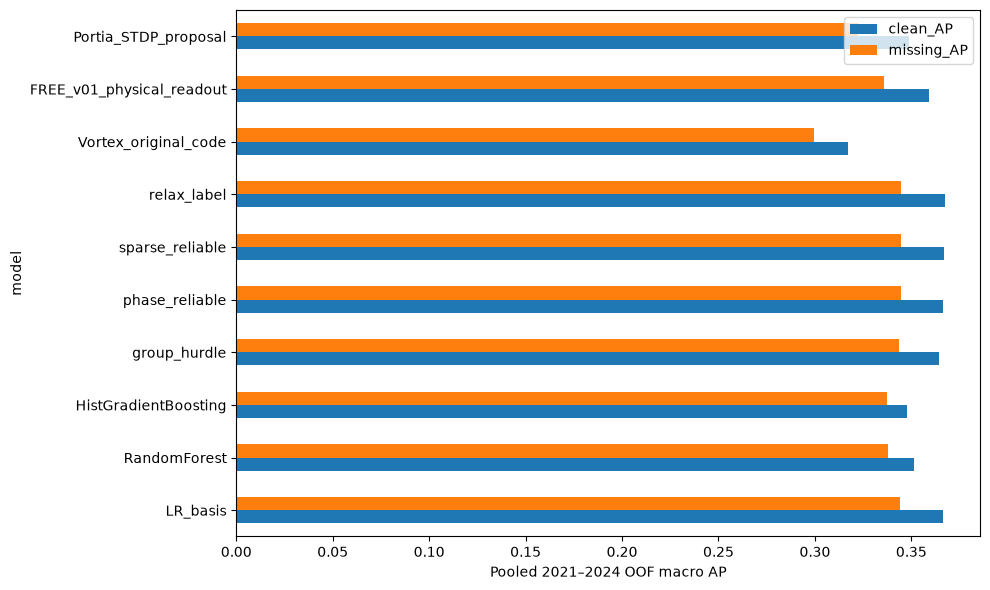

In [4]:
rows=[]
for scope,report in [('Common control',common),('Family specific',native)]:
    for name,a in report['models'].items():rows.append({'scope':scope,'model':name,'clean_AP':a['clean']['macro_ap'],'missing_AP':a['missing20']['macro_ap'],'Brier':a['clean']['macro_brier']})
table=pd.DataFrame(rows);display(table)
table.set_index('model')[['clean_AP','missing_AP']].plot.barh(figsize=(10,6));plt.xlabel('Pooled 2021–2024 OOF macro AP');plt.tight_layout();plt.show()

## 모델별 학습 결과와 불확실성

Vortex는2학습률·최대30epoch, 일부 trial은 상한에 도달했다. 포르티아의 STDP 변화와 발화율도 저장했다. 같은 계산 시간이나 완전한 최적 튜닝을 주장하지 않는다.

In [5]:
training=[]
for fold,s in enumerate(native['selections'],1):
    for name,config in s.items():
        for t in config['trials']:training.append({'fold':fold,'model':name,'trial':t['trial'],'validation_AP':t['validation_score'],'best_epoch':t.get('best_epoch'),'epochs_run':t.get('epochs_run'),'fit_seconds':t['fit_seconds'],'STDP_change':t.get('plasticity_change_norm'),'firing_rate':t.get('mean_firing')})
display(pd.DataFrame(training))
display(pd.DataFrame({k:{e:v['ci95'] for e,v in a.items()} for k,a in native['paired_vs_LR'].items()}).T)

,fold,model,trial,validation_AP,best_epoch,epochs_run,fit_seconds,STDP_change,firing_rate
0,1,Vortex_original_code,0,0.352163,8.0,16.0,15.339575,NaN,NaN
1,1,Vortex_original_code,1,0.357277,23.0,30.0,25.586134,NaN,NaN
2,1,FREE_v01_physical_readout,0,0.376230,NaN,NaN,0.215432,NaN,NaN
3,1,FREE_v01_physical_readout,1,0.373466,NaN,NaN,0.399033,NaN,NaN
4,1,Portia_STDP_proposal,0,0.359660,NaN,NaN,0.202686,0.009055,0.170396
5,1,Portia_STDP_proposal,1,0.356613,NaN,NaN,0.249934,0.027189,0.170314
6,2,Vortex_original_code,0,0.317006,15.0,23.0,17.764680,NaN,NaN
7,2,Vortex_original_code,1,0.309774,2.0,10.0,7.739049,NaN,NaN
8,2,FREE_v01_physical_readout,0,0.323608,NaN,NaN,0.208598,NaN,NaN
9,2,FREE_v01_physical_readout,1,0.319324,NaN,NaN,0.408977,NaN,NaN


,clean,missing20
Vortex_original_code,"[-0.06615729657531298, -0.030956095990887954]","[-0.057833055254523064, -0.0326105774038152]"
FREE_v01_physical_readout,"[-0.012999953030102094, -0.0011522985665617645]","[-0.013036436876468764, -0.0036686901658094114]"
Portia_STDP_proposal,"[-0.02509660586815159, -0.011445995774004599]","[-0.02703047329897058, -0.016870268001752734]"


## 활용 판단

실용적인 기준 선택은LR_basis. 공통 틀의 희소/이완 어댑터 개선은 작으며 원형 모델의 우월성으로 바꿔 말하지 않는다. 원형/설계 기반 후보는 이번 정적 건강자료·제한된 설정에서 큰 이득이 확인되지 않았다.

2024년만의 이전 결과와 직접 비교하면 표본 구성이 달라진다. 이번 검증도 이미 확인한 자료이므로 탐색적이고 새 연도 외삽이 아니다. 저장된 기존 실행 가중치(v5/v7/v8)와 이번 OOF 평가 모델을 구분한다.